This notebook implements a pipeline for detecting parasites  using the Segment Anything Model (SAM).

**Model Architecture**

We fine-tune SAM using Low-Rank Adaptation (LoRA), which injects small trainable matrices into the image encoder's attention layers while keeping the base weights frozen. The mask decoder is fully trainable.

**Preprocessing and Tiling**

Full-resolution specimen images are preprocessed with CLAHE for contrast enhancement, then split into fixed 1024×1024 tiles. Only tiles containing annotated parasites are retained for training. Edge tiles are zero-padded to maintain consistent dimensions.

**Loss Function**

Training uses a weighted combination of Binary Cross-Entropy (BCE) and Dice loss:
- BCE provides pixel-wise supervision and stable gradients
- Dice loss directly optimizes the overlap metric and handles class imbalance

An optional positive class weight can be applied to BCE to penalize false negatives and improve recall.

**Model Selection**

The best model is selected based on validation recall rather than Dice score. This prioritizes detection sensitivity, ensuring parasites are not missed, which is critical for biological specimen analysis where false negatives are more costly than false positives. Checkpoints are saved whenever validation recall improves, with early stopping available if no improvement is seen for a specified number of epochs.

In [ ]:
import os
!git clone https://github.com/ia-project-parasite/IA-PROJECT-PARASITE-REPO.git
os.chdir('IA-PROJECT-PARASITE-REPO')

Cloning into 'IA-PROJECT-PARASITE-REPO'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 431 (delta 20), reused 77 (delta 16), pack-reused 345 (from 1)
Receiving objects: 100% (431/431), 730.61 MiB | 17.48 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (206/206), done.


In [ ]:
!pip install -q torch torchvision
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python scikit-image pandas numpy matplotlib tqdm scikit-learn
!pip install -q loralib

  Preparing metadata (setup.py) ... done


In [ ]:
import os
import cv2
import numpy as np
import json
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import random
import shutil
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from segment_anything import sam_model_registry
import loralib as lora  # LoRA library
import pandas as pd

## Loading from Google Collab

The tiled dataset was generated once and saved to Google Drive. We load it here to avoid reprocessing.

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/Parasite_Dataset_Processed'

Mounted at /content/drive


## Split Dataset (Train/Val/Test)

In [ ]:
splits = {
    'train': [
        'B2025-00085e', 'B2025-00085k',
        'B2025-00150a', 'B2025-00150c',
        'B2025-00130b', 'B2025-00130c',
        'B2025-00158a', 'B2025-00158b',
        'B2025-00172a', 'B2025-00172b',
        'B2025-00173a', 'B2025-00173b',
        'B2025-00141a', 'B2025-00141c',
        'B2025-00176a', 'B2025-00176b',
        'B2025-00153a',
        'B2025-00146c', 'B2025-00137b',
        'B2025-00149d', 'B2025-00146a',
        'B2025-00144b', 'B2025-00156a',
        'B2025-00155e', 'B2025-00139b',
        'B2025-00137d',
        'B2025-00086a', 'B2025-00140b'
    ],

    'val': [
        'B2025-00234a', 'B2025-00084n',
        'B2025-00139a', 'B2025-00139a-1',
        'B2025-00138b', 'B2025-00171a',
        'B2025-00182c'
    ],

    'test': [
        'B2025-00231b', 'B2025-00143b',
        'B2025-00206b', 'B2025-00136b',
        'B2025-00085.2', 'B2025-00142a'
    ]
}

print(f"Train: {len(splits['train'])} images")
print(f"Val:   {len(splits['val'])} images")
print(f"Test:  {len(splits['test'])} images")
print(f"\nTrain images: {splits['train']}")
print(f"Val images:   {splits['val']}")
print(f"Test images:  {splits['test']}")

Train: 28 images
Val:   7 images
Test:  6 images

Train images: ['B2025-00085e', 'B2025-00085k', 'B2025-00150a', 'B2025-00150c', 'B2025-00130b', 'B2025-00130c', 'B2025-00158a', 'B2025-00158b', 'B2025-00172a', 'B2025-00172b', 'B2025-00173a', 'B2025-00173b', 'B2025-00141a', 'B2025-00141c', 'B2025-00176a', 'B2025-00176b', 'B2025-00153a', 'B2025-00146c', 'B2025-00137b', 'B2025-00149d', 'B2025-00146a', 'B2025-00144b', 'B2025-00156a', 'B2025-00155e', 'B2025-00139b', 'B2025-00137d', 'B2025-00086a', 'B2025-00140b']
Val images:   ['B2025-00234a', 'B2025-00084n', 'B2025-00139a', 'B2025-00139a-1', 'B2025-00138b', 'B2025-00171a', 'B2025-00182c']
Test images:  ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']


## Dataset Class for PyTorch

The `SAMDatasetNoPrompt` class loads tile-mask pairs. It applies optional geometric augmentations (flips, 90° rotations) and returns normalized tensors.

In [ ]:
class SAMDatasetNoPrompt(Dataset):
    """Dataset for SAM fine-tuning"""

    def __init__(self, image_ids, output_dir, augment=False):
        self.samples = []
        self.augment = augment

        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            masks_dir = os.path.join(output_dir, img_id, "masks")
            annotations_dir = os.path.join(output_dir, img_id, "annotations")

            if not os.path.exists(tiles_dir):
                continue

            tile_files = [f for f in os.listdir(tiles_dir) if f.endswith('.png')]

            for tile_file in tile_files:
                tile_id = tile_file.replace('.png', '')
                tile_path = os.path.join(tiles_dir, tile_file)
                mask_path = os.path.join(masks_dir, f"{tile_id}.png")
                anno_path = os.path.join(annotations_dir, f"{tile_id}.json")

                if os.path.exists(mask_path) and os.path.exists(anno_path):
                    with open(anno_path, 'r') as f:
                        anno = json.load(f)

                    self.samples.append({
                        'tile_path': tile_path,
                        'mask_path': mask_path,
                        'tile_id': tile_id,
                        'base_image_id': img_id,
                        'num_parasites': anno['num_parasites']
                    })

        print(f"Loaded {len(self.samples)} samples (augment={augment})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image and mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)
        binary_mask = (mask > 127).astype(np.float32)

        if self.augment:
            if random.random() > 0.5:
                image = cv2.flip(image, 1).copy()
                binary_mask = cv2.flip(binary_mask, 1).copy()
            if random.random() > 0.5:
                image = cv2.flip(image, 0).copy()
                binary_mask = cv2.flip(binary_mask, 0).copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

        # Convert to tensors
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'tile_id': sample['tile_id'],
            'num_parasites': sample['num_parasites']
        }

## SAM Fine-Tuner with LoRA



The `SAMFineTuner_LoRA` class implements parameter-efficient fine-tuning using Low-Rank Adaptation. LoRA injects small trainable matrices into the image encoder's attention layers (specifically the QKV projections) while keeping the base weights frozen. The mask decoder is fully trainable, and the prompt encoder remains frozen since we use prompt-free inference. The combined loss function weights BCE and Dice losses, with optional positive class weighting to handle the sparse nature of parasite annotations.

In [ ]:
class SAMFineTuner_LoRA:
    """
    Fine-tuner for Segment Anything Model (SAM) using Low-Rank Adaptation (LoRA).

    LoRA enables parameter-efficient fine-tuning by injecting trainable low-rank
    matrices into the attention layers while keeping the base model frozen. This
    reduces memory requirements and training time while preserving pretrained knowledge.

    Training strategy:
        - Image encoder: Frozen except for LoRA adapters on QKV projections
        - Prompt encoder: Fully frozen (no prompts used)
        - Mask decoder: Fully trainable
    """

    def __init__(self, sam_model, device, learning_rate=1e-4, lora_rank=8,
                optimizer_type='adam', weight_decay=1e-4,
                bce_weight=1.0, dice_weight=1.0, grad_clip=None,
                pos_weight=1.0):
        """
        Initialize SAM fine-tuner with LoRA configuration.

        Args:
            sam_model: Pretrained SAM model instance
            device: Target device ('cuda' or 'cpu')
            learning_rate: Learning rate for optimizer (default: 1e-4)
            lora_rank: Rank of LoRA decomposition matrices (default: 8)
            optimizer_type: Optimizer choice - 'adam', 'adamw', or 'sgd'
            weight_decay: L2 regularization strength (default: 1e-4)
            bce_weight: Weight for binary cross-entropy loss (default: 1.0)
            dice_weight: Weight for Dice loss (default: 1.0)
            grad_clip: Maximum gradient norm for clipping (default: None)
            pos_weight: Weight for positive class in BCE loss (default: 1.0)
                        Values > 1.0 penalize false negatives more heavily,
                        which can improve recall for sparse targets
        """
        self.sam = sam_model
        self.device = device
        self.lora_rank = lora_rank
        self.grad_clip = grad_clip
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.pos_weight = pos_weight

        # Inject LoRA adapters into image encoder attention layers
        self._apply_lora_to_image_encoder()

        # Freeze base image encoder, keep only LoRA parameters trainable
        for name, param in self.sam.image_encoder.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Freeze prompt encoder entirely (not used in prompt-free mode)
        for param in self.sam.prompt_encoder.parameters():
            param.requires_grad = False

        # Train mask decoder fully
        for param in self.sam.mask_decoder.parameters():
            param.requires_grad = True

        # Collect trainable parameters: LoRA adapters + mask decoder
        lora_params = [p for n, p in self.sam.image_encoder.named_parameters()
                      if 'lora' in n and p.requires_grad]
        decoder_params = list(self.sam.mask_decoder.parameters())
        trainable_params = lora_params + decoder_params

        # Initialize optimizer based on specified type
        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(
                trainable_params,
                lr=learning_rate
            )
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(
                trainable_params,
                lr=learning_rate,
                weight_decay=weight_decay
            )
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(
                trainable_params,
                lr=learning_rate,
                momentum=0.9,
                weight_decay=weight_decay
            )
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_type}")

        # Configure BCE loss with optional positive class weighting
        # Higher pos_weight helps with class imbalance (sparse parasites)
        if pos_weight > 1.0:
            self.bce_loss = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([pos_weight]).to(device)
            )
            print(f"Using pos_weight={pos_weight} (prioritizing detection recall)")
        else:
            self.bce_loss = nn.BCEWithLogitsLoss()

        self.dice_loss = self.dice_loss_fn

        # Log parameter counts for verification
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params_count = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params_count = sum(p.numel() for p in lora_params)

        print(f"Trainable parameters:    {trainable_params_count:,} ({100*trainable_params_count/total_params:.2f}%)")
        print(f"  - LoRA parameters:     {lora_params_count:,}")
        print(f"  - Decoder parameters:  {trainable_params_count - lora_params_count:,}")


    def _apply_lora_to_image_encoder(self):
        """
        Apply LoRA adapters to QKV projection layers in each transformer block.

        For each attention layer, the original linear projection is replaced with
        a LoRA-augmented version that adds a low-rank update: W' = W + BA
        where B and A are the trainable low-rank matrices.
        """
        for block_idx, block in enumerate(self.sam.image_encoder.blocks):
            attn = block.attn
            original_qkv = attn.qkv
            in_features = original_qkv.in_features
            out_features = original_qkv.out_features

            # Preserve original pretrained weights
            original_weight = original_qkv.weight.data.clone()
            original_bias = original_qkv.bias.data.clone() if original_qkv.bias is not None else None

            # Create LoRA-augmented linear layer
            # lora_alpha controls the scaling of the low-rank update
            lora_qkv = lora.Linear(
                in_features,
                out_features,
                r=self.lora_rank,
                lora_alpha=self.lora_rank * 2,
                lora_dropout=0.1,
                merge_weights=False,
                bias=original_qkv.bias is not None
            )

            # Copy pretrained weights to new layer (LoRA matrices initialized separately)
            with torch.no_grad():
                lora_qkv.weight.copy_(original_weight)
                if original_bias is not None:
                    lora_qkv.bias.copy_(original_bias)

            # Replace original layer with LoRA version
            attn.qkv = lora_qkv.to(self.device)

        print(f"Applied LoRA (rank={self.lora_rank}) to {len(self.sam.image_encoder.blocks)} transformer blocks")


    def dice_loss_fn(self, pred, target, smooth=1e-5):
        """
        Compute Dice loss for segmentation.

        Dice loss directly optimizes the Dice coefficient, which measures
        overlap between prediction and ground truth. More robust to class
        imbalance than pixel-wise cross-entropy alone.

        Args:
            pred: Predicted logits (B, 1, H, W)
            target: Ground truth binary masks (B, 1, H, W)
            smooth: Smoothing term to avoid division by zero

        Returns:
            Scalar Dice loss (1 - Dice coefficient)
        """
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def compute_metrics(self, pred, target, threshold=0.5):
        """
        Compute confusion matrix components for metric accumulation.

        Returns raw counts (TP, FP, FN, TN) rather than final metrics
        to enable proper aggregation across batches.

        Args:
            pred: Predicted logits
            target: Ground truth masks
            threshold: Binarization threshold for predictions

        Returns:
            Dictionary with tp, fp, fn, tn counts
        """
        pred_binary = (torch.sigmoid(pred) > threshold).float()
        target_binary = target.float()

        pred_flat = pred_binary.view(-1)
        target_flat = target_binary.view(-1)

        tp = (pred_flat * target_flat).sum()
        fp = (pred_flat * (1 - target_flat)).sum()
        fn = ((1 - pred_flat) * target_flat).sum()
        tn = ((1 - pred_flat) * (1 - target_flat)).sum()

        return {
            'tp': tp.item(),
            'fp': fp.item(),
            'fn': fn.item(),
            'tn': tn.item()
        }

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_tn):
        """
        Compute final evaluation metrics from accumulated confusion matrix counts.

        Args:
            total_tp: Total true positives across all batches
            total_fp: Total false positives
            total_fn: Total false negatives
            total_tn: Total true negatives

        Returns:
            Dictionary with IoU, Dice, precision, recall, and F1 scores
        """
        smooth = 1e-7
        iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
        dice = (2 * total_tp + smooth) / (2 * total_tp + total_fp + total_fn + smooth)
        precision = (total_tp + smooth) / (total_tp + total_fp + smooth)
        recall = (total_tp + smooth) / (total_tp + total_fn + smooth)
        f1 = (2 * precision * recall) / (precision + recall + smooth)

        return {
            'iou': iou,
            'dice': dice,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def train_step(self, batch):
        """
        Execute single training step with forward pass, loss computation, and weight update.

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.train()
        self.optimizer.zero_grad()

        # Move data to device
        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass through image encoder (LoRA adapters active)
        image_embeddings = self.sam.image_encoder(images)

        # Get empty prompt embeddings (prompt-free mode)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        # Generate mask predictions
        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # Upsample to original resolution for loss computation
        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Compute combined loss with configurable weights
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        # Backward pass
        loss.backward()

        # Optional gradient clipping for training stability
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.sam.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )

        # Update weights
        self.optimizer.step()

        # Compute metrics without gradient tracking
        with torch.no_grad():
            metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    @torch.no_grad()
    def val_step(self, batch):
        """
        Execute validation step (inference only, no gradient computation).

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.eval()

        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass (same as training but without gradients)
        image_embeddings = self.sam.image_encoder(images)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Compute losses and metrics
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    def save_checkpoint(self, path):
        """
        Save model checkpoint with LoRA weights, decoder state, and optimizer.

        Only saves the trainable components (not the frozen base model),
        keeping checkpoint files compact.

        Args:
            path: File path for checkpoint
        """
        torch.save({
            'mask_decoder': self.sam.mask_decoder.state_dict(),
            'lora_state': {n: p.data for n, p in self.sam.image_encoder.named_parameters() if 'lora' in n},
            'optimizer': self.optimizer.state_dict()
        }, path)
        print(f"Checkpoint saved to {path}")

    def load_checkpoint(self, path, load_optimizer=True):
        """
        Load model checkpoint and restore LoRA weights and decoder state.

        Args:
            path: Path to checkpoint file
            load_optimizer: Whether to restore optimizer state (for resuming training)
        """
        checkpoint = torch.load(path, map_location=self.device)
        self.sam.mask_decoder.load_state_dict(checkpoint['mask_decoder'])

        # Restore LoRA adapter weights
        if 'lora_state' in checkpoint:
            for name, param in self.sam.image_encoder.named_parameters():
                if name in checkpoint['lora_state']:
                    param.data.copy_(checkpoint['lora_state'][name])

        # Optionally restore optimizer state for training continuation
        if load_optimizer and 'optimizer' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            print("Optimizer state loaded")

        print(f"Checkpoint loaded from {path}")

## Training Function

The `train_sam_lora` function runs the complete training pipeline. It accumulates confusion matrix components across batches for accurate epoch-level metrics, supports multiple learning rate schedulers (cosine, plateau, step), and saves checkpoints to Google Drive. The best model is selected based on validation recall to prioritize parasite detection, with early stopping available if no improvement is seen.

In [ ]:
def train_sam_lora(sam_model, train_dataset, val_dataset, config, save_to_drive=True):
    """
    Main training loop for SAM fine-tuning with LoRA.

    Handles the complete training pipeline including:
        - DataLoader setup
        - LoRA fine-tuner initialization
        - Learning rate scheduling
        - Metric tracking and logging
        - Checkpoint saving (best, periodic, final)
        - Early stopping based on validation recall

    Args:
        sam_model: Pretrained SAM model to fine-tune
        train_dataset: Training dataset (SAMDatasetNoPrompt instance)
        val_dataset: Validation dataset
        config: Dictionary containing training hyperparameters:
            - exp_name: Experiment name for checkpoint directory
            - batch_size: Batch size for training
            - num_epochs: Maximum number of training epochs
            - learning_rate: Initial learning rate
            - lora_rank: Rank for LoRA adapters (default: 8)
            - optimizer: 'adam', 'adamw', or 'sgd' (default: 'adam')
            - weight_decay: L2 regularization (default: 1e-4)
            - bce_weight: Weight for BCE loss (default: 1.0)
            - dice_weight: Weight for Dice loss (default: 1.0)
            - pos_weight: Positive class weight for BCE (default: 1.0)
            - grad_clip: Max gradient norm (default: None)
            - scheduler: 'cosine', 'plateau', 'step', or None
            - early_stop_patience: Epochs without improvement before stopping
        save_to_drive: If True, save checkpoints to Google Drive

    Returns:
        history: Dictionary containing training/validation metrics per epoch
        fine_tuner: Trained SAMFineTuner_LoRA instance
        checkpoint_dir: Path to saved checkpoints
    """
    # Extract configuration parameters
    exp_name = config['exp_name']
    batch_size = config['batch_size']
    num_epochs = config['num_epochs']
    learning_rate = config['learning_rate']
    lora_rank = config.get('lora_rank', 8)
    optimizer_type = config.get('optimizer', 'adam')
    weight_decay = config.get('weight_decay', 1e-4)
    bce_weight = config.get('bce_weight', 1.0)
    dice_weight = config.get('dice_weight', 1.0)
    pos_weight = config.get('pos_weight', 1.0)
    grad_clip = config.get('grad_clip', None)
    scheduler_type = config.get('scheduler', None)
    early_stop_patience = config.get('early_stop_patience', None)

    # Setup checkpoint directory (Google Drive for persistence across Colab sessions)
    if save_to_drive:
        checkpoint_dir = f"/content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/{exp_name}"
    else:
        checkpoint_dir = f"sam_checkpoints/{exp_name}"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"Checkpoints will be saved to: {checkpoint_dir}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam_model.to(device)

    # Initialize LoRA fine-tuner with all configuration options
    fine_tuner = SAMFineTuner_LoRA(
        sam_model,
        device,
        learning_rate=learning_rate,
        lora_rank=lora_rank,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        bce_weight=bce_weight,
        dice_weight=dice_weight,
        grad_clip=grad_clip,
        pos_weight=pos_weight,
    )

    # Setup learning rate scheduler if specified
    scheduler = None
    if scheduler_type == 'cosine':
        # Smooth decay to minimum LR over training duration
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            fine_tuner.optimizer, T_max=num_epochs, eta_min=1e-6
        )
        print("Using CosineAnnealingLR scheduler")
    elif scheduler_type == 'plateau':
        # Reduce LR when validation loss plateaus
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            fine_tuner.optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        print("Using ReduceLROnPlateau scheduler")
    elif scheduler_type == 'step':
        # Fixed LR decay every N epochs
        scheduler = torch.optim.lr_scheduler.StepLR(
            fine_tuner.optimizer, step_size=10, gamma=0.5
        )
        print("Using StepLR scheduler")

    # Initialize training history for all tracked metrics
    history = {
        'train_loss': [], 'train_loss_bce': [], 'train_loss_dice': [],
        'train_iou': [], 'train_dice': [], 'train_precision': [],
        'train_recall': [], 'train_f1': [],
        'val_loss': [], 'val_loss_bce': [], 'val_loss_dice': [],
        'val_iou': [], 'val_dice': [], 'val_precision': [],
        'val_recall': [], 'val_f1': []
    }

    # Track best model based on validation recall (prioritize detection)
    best_val_recall = 0.0
    best_epoch = 0
    patience_counter = 0

    # Main training loop
    for epoch in range(num_epochs):

        # ==================== TRAINING PHASE ====================
        # Accumulate confusion matrix components across batches
        train_losses = []
        train_losses_bce = []
        train_losses_dice = []
        train_tp = train_fp = train_fn = train_tn = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in pbar:
            step_results = fine_tuner.train_step(batch)

            # Accumulate losses
            train_losses.append(step_results['loss'])
            train_losses_bce.append(step_results['loss_bce'])
            train_losses_dice.append(step_results['loss_dice'])

            # Accumulate confusion matrix components
            train_tp += step_results['tp']
            train_fp += step_results['fp']
            train_fn += step_results['fn']
            train_tn += step_results['tn']

            # Compute running metrics for progress bar
            running_metrics = fine_tuner.compute_final_metrics(
                train_tp, train_fp, train_fn, train_tn
            )
            pbar.set_postfix({
                "loss": f"{step_results['loss']:.4f}",
                "dice": f"{running_metrics['dice']:.4f}",
                "iou": f"{running_metrics['iou']:.4f}",
            })

        # ==================== VALIDATION PHASE ====================
        val_losses = []
        val_losses_bce = []
        val_losses_dice = []
        val_tp = val_fp = val_fn = val_tn = 0

        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            step_results = fine_tuner.val_step(batch)

            val_losses.append(step_results['loss'])
            val_losses_bce.append(step_results['loss_bce'])
            val_losses_dice.append(step_results['loss_dice'])

            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_tn += step_results['tn']

        # Compute final epoch metrics from accumulated counts
        train_metrics = fine_tuner.compute_final_metrics(train_tp, train_fp, train_fn, train_tn)
        val_metrics = fine_tuner.compute_final_metrics(val_tp, val_fp, val_fn, val_tn)

        # Record metrics to history
        history['train_loss'].append(np.mean(train_losses))
        history['train_loss_bce'].append(np.mean(train_losses_bce))
        history['train_loss_dice'].append(np.mean(train_losses_dice))
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['train_precision'].append(train_metrics['precision'])
        history['train_recall'].append(train_metrics['recall'])
        history['train_f1'].append(train_metrics['f1'])

        history['val_loss'].append(np.mean(val_losses))
        history['val_loss_bce'].append(np.mean(val_losses_bce))
        history['val_loss_dice'].append(np.mean(val_losses_dice))
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        # Extract current epoch metrics for logging
        avg_train_loss = history['train_loss'][-1]
        avg_train_dice = history['train_dice'][-1]
        avg_train_iou = history['train_iou'][-1]
        avg_train_precision = history['train_precision'][-1]
        avg_train_recall = history['train_recall'][-1]
        avg_train_f1 = history['train_f1'][-1]

        avg_val_loss = history['val_loss'][-1]
        avg_val_dice = history['val_dice'][-1]
        avg_val_iou = history['val_iou'][-1]
        avg_val_precision = history['val_precision'][-1]
        avg_val_recall = history['val_recall'][-1]
        avg_val_f1 = history['val_f1'][-1]

        # Update learning rate scheduler
        if scheduler is not None:
            if scheduler_type == 'plateau':
                scheduler.step(avg_val_loss)  # Plateau scheduler uses validation loss
            else:
                scheduler.step()

        # Log epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f" Train | Loss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f} | IoU: {avg_train_iou:.4f}")
        print(f"       | Precision: {avg_train_precision:.4f} | Recall: {avg_train_recall:.4f} | F1: {avg_train_f1:.4f}")
        print(f" Val   | Loss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f}")
        print(f"       | Precision: {avg_val_precision:.4f} | Recall: {avg_val_recall:.4f} | F1: {avg_val_f1:.4f}")

        # Save best model based on validation recall
        if avg_val_recall > best_val_recall:
            best_val_recall = avg_val_recall
            best_epoch = epoch + 1
            patience_counter = 0

            # Save comprehensive checkpoint with all metadata
            best_checkpoint_path = os.path.join(checkpoint_dir, "sam_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_recall': best_val_recall,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'history': history,
                'lora_rank': lora_rank,
                'bce_weight': bce_weight,
                'dice_weight': dice_weight,
                'config': config,
            }, best_checkpoint_path)
            print(f"\nNew best model saved (Recall: {best_val_recall:.4f})")
        else:
            patience_counter += 1

        # Check early stopping condition
        if early_stop_patience is not None and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # Save periodic checkpoint every 5 epochs (for training resumption)
        if (epoch + 1) % 5 == 0:
            epoch_checkpoint_path = os.path.join(checkpoint_dir, f"sam_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'lora_rank': lora_rank,
                'config': config,
            }, epoch_checkpoint_path)
            print(f"Checkpoint saved: epoch_{epoch+1}.pth\n")

    # Save final model with complete training history
    final_checkpoint_path = os.path.join(checkpoint_dir, "sam_final.pth")
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': fine_tuner.sam.state_dict(),
        'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
        'final_val_dice': avg_val_dice,
        'best_val_recall': best_val_recall,
        'best_epoch': best_epoch,
        'lora_rank': lora_rank,
        'config': config,
        'history': history,
    }, final_checkpoint_path)

    return history, fine_tuner, checkpoint_dir

## Evaluation Functions

In [ ]:
def plot_all_metrics(history):
    """
    Plot all training metrics in a 3x3 grid.

    Args:
        history: Training history dictionary
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    # Losses
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Total Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history['train_loss_bce'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_loss_bce'], label='Validation', linewidth=2)
    axes[0, 1].set_title('BCE Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(history['train_loss_dice'], label='Train', linewidth=2)
    axes[0, 2].plot(history['val_loss_dice'], label='Validation', linewidth=2)
    axes[0, 2].set_title('Dice Loss', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Main Segmentation Metrics
    axes[1, 0].plot(history['train_dice'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_dice'], label='Validation', linewidth=2)
    axes[1, 0].set_title('Dice Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    axes[1, 1].plot(history['train_iou'], label='Train', linewidth=2)
    axes[1, 1].plot(history['val_iou'], label='Validation', linewidth=2)
    axes[1, 1].set_title('IoU (Intersection over Union)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0, 1])

    axes[1, 2].plot(history['train_f1'], label='Train', linewidth=2)
    axes[1, 2].plot(history['val_f1'], label='Validation', linewidth=2)
    axes[1, 2].set_title('F1 Score', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim([0, 1])

    # Precision and Recall
    axes[2, 0].plot(history['train_precision'], label='Train', linewidth=2)
    axes[2, 0].plot(history['val_precision'], label='Validation', linewidth=2)
    axes[2, 0].set_title('Precision', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Score')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].set_ylim([0, 1])

    axes[2, 1].plot(history['train_recall'], label='Train', linewidth=2)
    axes[2, 1].plot(history['val_recall'], label='Validation', linewidth=2)
    axes[2, 1].set_title('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Score')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].set_ylim([0, 1])

    # Hide the empty subplot
    axes[2, 2].axis('off')

    plt.suptitle('SAM Fine-tuning: Training Curves', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

Helper functions for model inference and evaluation.

`predict_mask` runs prompt-free inference on a single image, `calculate_segmentation_metrics` computes Dice/IoU/precision/recall from binary masks and `create_overlay_images` generates color-coded visualizations for qualitative comparison.

In [ ]:
def predict_mask(fine_tuner, image_tensor):
    """
    Predict segmentation mask for a single image using the fine-tuned SAM model.

    Args:
        fine_tuner: SAMFineTuner_LoRA instance with trained weights
        image_tensor: Input image tensor of shape [1, 3, H, W] on device

    Returns:
        pred_mask: Predicted mask as [H, W] numpy array with sigmoid probabilities (0-1)
    """
    fine_tuner.sam.eval()

    with torch.no_grad():
        # Extract image features through LoRA-adapted encoder
        image_embeddings = fine_tuner.sam.image_encoder(image_tensor)

        # Get empty prompt embeddings (prompt-free inference)
        sparse_embeddings, dense_embeddings = fine_tuner.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(fine_tuner.device)
        dense_embeddings = dense_embeddings.to(fine_tuner.device)

        # Generate low-resolution mask prediction
        low_res_masks, _ = fine_tuner.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=fine_tuner.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # Upsample to original input resolution
        pred_masks = torch.nn.functional.interpolate(
            low_res_masks,
            size=image_tensor.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Convert logits to probabilities and move to CPU
        pred_mask = torch.sigmoid(pred_masks[0, 0]).cpu().numpy()

    return pred_mask


def calculate_segmentation_metrics(pred_binary, mask_gt_binary):
    """
    Calculate standard segmentation metrics from binary masks.

    Computes confusion matrix components and derived metrics for
    evaluating segmentation quality.

    Args:
        pred_binary: Predicted binary mask [H, W] with values 0 or 1
        mask_gt_binary: Ground truth binary mask [H, W] with values 0 or 1

    Returns:
        Dictionary containing:
            - tp, fp, fn, tn: Confusion matrix counts
            - dice: Dice coefficient (F1 for segmentation)
            - iou: Intersection over Union (Jaccard index)
            - precision: Positive predictive value
            - recall: Sensitivity / true positive rate
    """
    # Compute confusion matrix components
    tp = np.sum((pred_binary > 0) & (mask_gt_binary > 0))   # True positives
    fp = np.sum((pred_binary > 0) & (mask_gt_binary == 0))  # False positives
    fn = np.sum((pred_binary == 0) & (mask_gt_binary > 0))  # False negatives
    tn = np.sum((pred_binary == 0) & (mask_gt_binary == 0)) # True negatives

    # Compute derived metrics (with smoothing to avoid division by zero)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn),
        'dice': dice,
        'iou': iou,
        'precision': precision,
        'recall': recall
    }


def create_overlay_images(full_image, mask_gt_binary, mask_pred_binary):
    """
    Create colored overlay visualizations for qualitative evaluation.

    Generates three overlay images:
        1. Ground truth overlay: Shows annotated regions
        2. Prediction overlay: Shows model predictions
        3. Comparison overlay: Shows agreement/disagreement between GT and prediction

    Args:
        full_image: RGB image [H, W, 3] with values normalized to 0-1
        mask_gt_binary: Ground truth binary mask [H, W]
        mask_pred_binary: Predicted binary mask [H, W]

    Returns:
        Dictionary with overlay images:
            - 'gt': Ground truth regions highlighted in yellow
            - 'pred': Predicted regions highlighted in cyan
            - 'comparison': Error analysis visualization
                - Green: True positives (correct detections)
                - Red: False positives (over-segmentation)
                - Blue: False negatives (missed regions)
    """
    # Ground truth overlay - yellow highlights
    overlay_gt = full_image.copy()
    overlay_gt[mask_gt_binary > 0] = [1, 1, 0]

    # Prediction overlay - cyan highlights
    overlay_pred = full_image.copy()
    overlay_pred[mask_pred_binary > 0] = [0, 1, 1]

    # Comparison overlay - color-coded error analysis
    overlay_comparison = full_image.copy()
    overlay_comparison[(mask_pred_binary > 0) & (mask_gt_binary > 0)] = [0, 1, 0]   # Green: TP
    overlay_comparison[(mask_pred_binary > 0) & (mask_gt_binary == 0)] = [1, 0, 0]  # Red: FP
    overlay_comparison[(mask_pred_binary == 0) & (mask_gt_binary > 0)] = [0, 0, 1]  # Blue: FN

    return {
        'gt': overlay_gt,
        'pred': overlay_pred,
        'comparison': overlay_comparison
    }

The `evaluate_on_test` function computes tile-level metrics on the held-out test set. It accumulates confusion matrix components across all batches for accurate aggregate metricsand optionally visualizes random predictions alongside ground truth.

In [ ]:
def evaluate_on_test(fine_tuner, test_dataset, batch_size=4, visualize=False, num_viz_samples=6):
    """
    Evaluate fine-tuned SAM model on tile-level test set.

    Computes aggregate segmentation metrics across all test tiles and
    optionally displays qualitative predictions for visual inspection.

    Args:
        fine_tuner: Trained SAMFineTuner_LoRA instance
        test_dataset: Test dataset (SAMDatasetNoPrompt instance)
        batch_size: Batch size for evaluation (default: 4)
        visualize: If True, display random sample predictions (default: False)
        num_viz_samples: Number of samples to visualize (default: 6)

    Returns:
        test_results: Dictionary containing:
            - loss, bce, dice_loss: Loss components
            - dice, iou, precision, recall, f1: Segmentation metrics
    """
    # Clear GPU memory before evaluation
    torch.cuda.empty_cache()

    # Create test loader with conservative memory settings
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    # Initialize accumulators for metrics
    test_losses = []
    test_losses_bce = []
    test_losses_dice = []
    test_tp = 0
    test_fp = 0
    test_fn = 0
    test_tn = 0

    # Evaluate all batches without gradient computation
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="Testing")):
            step_results = fine_tuner.val_step(batch)

            # Accumulate losses
            test_losses.append(step_results['loss'])
            test_losses_bce.append(step_results['loss_bce'])
            test_losses_dice.append(step_results['loss_dice'])

            # Accumulate confusion matrix components
            test_tp += step_results['tp']
            test_fp += step_results['fp']
            test_fn += step_results['fn']
            test_tn += step_results['tn']

            # Periodic memory cleanup to prevent OOM
            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

    # Compute final metrics from accumulated counts
    final_metrics = fine_tuner.compute_final_metrics(test_tp, test_fp, test_fn, test_tn)

    # Package results
    test_results = {
        'loss': np.mean(test_losses),
        'bce': np.mean(test_losses_bce),
        'dice_loss': np.mean(test_losses_dice),
        'iou': final_metrics['iou'],
        'dice': final_metrics['dice'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1']
    }


    print(f"TILE-LEVEL TEST RESULTS")
    print(f"Loss:          {test_results['loss']:.4f}")
    print(f"  - BCE Loss:  {test_results['bce']:.4f}")
    print(f"  - Dice Loss: {test_results['dice_loss']:.4f}")
    print(f"\nSegmentation Metrics:")
    print(f"  Dice:        {test_results['dice']:.4f}")
    print(f"  IoU:         {test_results['iou']:.4f}")
    print(f"  Precision:   {test_results['precision']:.4f}")
    print(f"  Recall:      {test_results['recall']:.4f}")
    print(f"  F1:          {test_results['f1']:.4f}")

    # Optional visualization of random test samples
    if visualize:
        print(f"Visualizing {num_viz_samples} random samples...\n")

        # Select random samples for visualization
        sample_indices = np.random.choice(
            len(test_dataset),
            min(num_viz_samples, len(test_dataset)),
            replace=False
        )

        # Create figure grid: each row shows image, ground truth, prediction
        fig, axes = plt.subplots(num_viz_samples, 3, figsize=(15, 5*num_viz_samples))
        if num_viz_samples == 1:
            axes = axes.reshape(1, -1)

        with torch.no_grad():
            for idx, sample_idx in enumerate(sample_indices):
                sample = test_dataset[sample_idx]

                # Run inference on single sample
                image = sample['image'].unsqueeze(0).to(fine_tuner.device)
                mask_gt = sample['mask'][0].cpu().numpy()

                pred_mask = predict_mask(fine_tuner, image)
                pred_binary = (pred_mask > 0.5).astype(np.float32)

                # Compute per-sample metrics for display
                metrics = calculate_segmentation_metrics(pred_binary, mask_gt)

                # Free GPU memory after each sample
                del image
                torch.cuda.empty_cache()

                # Convert image tensor to numpy for plotting
                image_np = sample['image'].permute(1, 2, 0).cpu().numpy()

                # Plot input image
                axes[idx, 0].imshow(image_np)
                axes[idx, 0].set_title(
                    f'Image\n{sample["tile_id"]}\nParasites: {sample["num_parasites"]}',
                    fontsize=11
                )
                axes[idx, 0].axis('off')

                # Plot ground truth mask
                axes[idx, 1].imshow(mask_gt, cmap='gray')
                axes[idx, 1].set_title('Ground Truth', fontsize=11)
                axes[idx, 1].axis('off')

                # Plot prediction with metrics
                axes[idx, 2].imshow(pred_binary, cmap='gray')
                axes[idx, 2].set_title(
                    f'Prediction\nDice: {metrics["dice"]:.3f} | IoU: {metrics["iou"]:.3f}',
                    fontsize=11
                )
                axes[idx, 2].axis('off')

        plt.suptitle('Test Set Predictions (Random Tiles)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return test_results

The `evaluate_full_images` function reconstructs full-resolution images from their tiles and computes whole-image metrics. This provides a more realistic evaluation than tile-level metrics since it accounts for stitching and reflects actual deployment performance.

In [ ]:
def evaluate_full_images(fine_tuner, splits, test_dataset,
                         max_image_size_mb=300,
                         process_in_chunks=True,
                         chunk_size=30,
                         save_visualizations=True,
                         output_dir="evaluation_results"):
    """
    Reconstruct full images from tiles and evaluate at the whole-image level.

    Since training uses tiles, this function reassembles predictions into
    full-resolution images for more meaningful evaluation. Handles memory
    constraints through chunked processing and dtype optimization.

    Visualization shows four columns per image:
        1. Original reconstructed image
        2. Ground truth mask
        3. Predicted mask
        4. Comparison overlay (TP=green, FP=red, FN=blue)

    Args:
        fine_tuner: Trained SAMFineTuner_LoRA instance
        splits: Dictionary containing 'test' key with list of test image IDs
        test_dataset: Test dataset with tile samples
        max_image_size_mb: Skip images larger than this (default: 300MB)
        process_in_chunks: If True, clear GPU cache periodically (default: True)
        chunk_size: Number of tiles between cache clears (default: 30)
        save_visualizations: If True, generate visualization plots (default: True)
        output_dir: Directory for saving results (default: "evaluation_results")

    Returns:
        results_df: DataFrame with per-image metrics
        all_visualizations: List of visualization dictionaries (if save_visualizations=True)
    """
    import os
    import json

    torch.cuda.empty_cache()
    test_image_ids = splits['test']

    all_results = []
    all_visualizations = [] if save_visualizations else None

    print(f"FULL IMAGE RECONSTRUCTION WITH VISUALIZATION")
    print(f"Testing on {len(test_image_ids)} images: {test_image_ids}\n")

    # Process each test image
    for image_id in test_image_ids:
        print(f"Processing: {image_id}...")

        # Collect all tiles belonging to this image
        image_tiles = [sample for sample in test_dataset.samples
                      if sample['base_image_id'] == image_id]

        if len(image_tiles) == 0:
            print(f"  No tiles found, skipping\n")
            continue

        # Load tile bounding boxes from annotation files
        bbox_map = {}
        for sample in image_tiles:
            anno_path = sample['mask_path'].replace('masks', 'annotations').replace('.png', '.json')
            if os.path.exists(anno_path):
                with open(anno_path, 'r') as f:
                    anno = json.load(f)
                    bbox_map[sample['tile_id']] = anno['tile_bbox']

        if len(bbox_map) == 0:
            print(f"  No bbox info found, skipping\n")
            continue

        # Determine full image dimensions from tile bounding boxes
        max_h = max([bbox[3] for bbox in bbox_map.values()])
        max_w = max([bbox[2] for bbox in bbox_map.values()])
        estimated_size_mb = (max_h * max_w * 3 * 4) / (1024 ** 2)

        # Skip images that would exceed memory limits
        if estimated_size_mb > max_image_size_mb:
            print(f"  Image too large ({estimated_size_mb:.1f}MB > {max_image_size_mb}MB), skipping\n")
            continue

        print(f"  Reconstructing: {max_w} x {max_h} (~{estimated_size_mb:.1f}MB, {len(image_tiles)} tiles)")

        # Use float16 for large images to reduce memory footprint
        dtype = np.float16 if estimated_size_mb > 100 else np.float32

        # Initialize accumulation arrays for tile stitching
        full_image = np.zeros((max_h, max_w, 3), dtype=dtype)
        full_mask_gt = np.zeros((max_h, max_w), dtype=dtype)
        full_mask_pred = np.zeros((max_h, max_w), dtype=dtype)
        tile_counts = np.zeros((max_h, max_w), dtype=np.int16)  # Track overlaps for averaging

        tiles_processed = 0

        try:
            with torch.no_grad():
                for tile_idx, sample in enumerate(image_tiles):
                    tile_id = sample['tile_id']
                    if tile_id not in bbox_map:
                        continue

                    x1, y1, x2, y2 = bbox_map[tile_id]

                    # Load tile image and ground truth mask
                    tile_img = cv2.cvtColor(cv2.imread(sample['tile_path']), cv2.COLOR_BGR2RGB)
                    mask_gt = (cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE) > 127).astype(dtype)

                    # Prepare tensor and run inference
                    image_tensor = torch.from_numpy(tile_img).permute(2, 0, 1).float() / 255.0
                    image_tensor = image_tensor.unsqueeze(0).to(fine_tuner.device)

                    # Handle potential GPU OOM errors gracefully
                    try:
                        pred_mask = predict_mask(fine_tuner, image_tensor)
                    except RuntimeError as e:
                        if "out of memory" in str(e):
                            print(f"  GPU OOM on tile {tile_idx+1}/{len(image_tiles)}")
                            torch.cuda.empty_cache()
                            try:
                                pred_mask = predict_mask(fine_tuner, image_tensor)
                            except:
                                print(f"  Still OOM, skipping remaining tiles")
                                break
                        else:
                            raise e

                    del image_tensor

                    # Handle edge tiles that were zero-padded during tiling
                    # Crop to actual valid region based on bounding box
                    bbox_h, bbox_w = y2 - y1, x2 - x1
                    if tile_img.shape[0] != bbox_h or tile_img.shape[1] != bbox_w:
                        tile_img = tile_img[:bbox_h, :bbox_w]
                        mask_gt = mask_gt[:bbox_h, :bbox_w]
                        pred_mask = pred_mask[:bbox_h, :bbox_w]

                    # Accumulate tile contributions to full image
                    full_image[y1:y2, x1:x2] += tile_img.astype(dtype) / 255.0
                    full_mask_gt[y1:y2, x1:x2] += mask_gt
                    full_mask_pred[y1:y2, x1:x2] += pred_mask.astype(dtype)
                    tile_counts[y1:y2, x1:x2] += 1

                    tiles_processed += 1

                    # Periodic memory cleanup for large images
                    if process_in_chunks and (tile_idx + 1) % chunk_size == 0:
                        torch.cuda.empty_cache()
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles (cleared cache)")
                    elif (tile_idx + 1) % 20 == 0:
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles")

                print(f"  Successfully processed {tiles_processed}/{len(image_tiles)} tiles")

        except Exception as e:
            print(f"  Error processing image: {e}, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            torch.cuda.empty_cache()
            continue

        if tiles_processed == 0:
            print(f"  No tiles were successfully processed, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            continue

        # Average overlapping regions (non-overlapping tiles have count=1)
        tile_counts[tile_counts == 0] = 1  # Avoid division by zero
        full_image = np.clip(full_image / tile_counts[:, :, np.newaxis], 0, 1).astype(np.float32)
        full_mask_gt_binary = (full_mask_gt / tile_counts > 0.5).astype(np.uint8)
        full_mask_pred_binary = (full_mask_pred / tile_counts > 0.5).astype(np.uint8)

        # Calculate full-image metrics
        metrics = calculate_segmentation_metrics(full_mask_pred_binary, full_mask_gt_binary)
        metrics['image_id'] = image_id
        metrics['tiles_processed'] = tiles_processed
        metrics['tiles_total'] = len(image_tiles)
        all_results.append(metrics)

        print(f"  Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f} | "
              f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}\n")

        # Store visualization data if requested
        if save_visualizations:
            # Create comparison overlay with color-coded errors
            overlay_comparison = full_image.copy()
            overlay_comparison[(full_mask_pred_binary > 0) & (full_mask_gt_binary > 0)] = [0, 1, 0]   # Green: TP
            overlay_comparison[(full_mask_pred_binary > 0) & (full_mask_gt_binary == 0)] = [1, 0, 0]  # Red: FP
            overlay_comparison[(full_mask_pred_binary == 0) & (full_mask_gt_binary > 0)] = [0, 0, 1]  # Blue: FN

            all_visualizations.append({
                'image_id': image_id,
                'full_image': full_image,
                'mask_gt': full_mask_gt_binary,
                'mask_pred': full_mask_pred_binary,
                'overlay_comparison': overlay_comparison,
                'metrics': metrics
            })

        # Clean up memory before next image
        del full_image, full_mask_gt, full_mask_pred, full_mask_gt_binary, full_mask_pred_binary, tile_counts
        torch.cuda.empty_cache()

    # Check if any images were processed
    if len(all_results) == 0:
        print("ERROR: No images were successfully processed!")
        return None, None

    # Create summary DataFrame
    results_df = pd.DataFrame(all_results)

    # Print per-image results table
    print("\n" + "="*70)
    print("PER IMAGE RESULTS")
    print("="*70)
    print(results_df[['image_id', 'dice', 'iou', 'precision', 'recall',
                      'tiles_processed', 'tiles_total']].to_string(index=False))

    # Print aggregate statistics
    print("\n" + "="*70)
    print("AVERAGE METRICS ACROSS ALL IMAGES")
    print("="*70)
    for metric in ['dice', 'iou', 'precision', 'recall']:
        mean_val = results_df[metric].mean()
        std_val = results_df[metric].std()
        print(f"{metric.capitalize():10s}: {mean_val:.4f} ± {std_val:.4f}")

    # Generate visualization grid
    if save_visualizations and len(all_visualizations) > 0:
        print("\nCreating visualizations...")

        num_images = len(all_visualizations)
        fig, axes = plt.subplots(num_images, 4, figsize=(20, 5*num_images))

        # Handle single image case
        if num_images == 1:
            axes = axes.reshape(1, -1)

        for idx, viz in enumerate(all_visualizations):
            metrics = viz['metrics']

            # Column 1: Original reconstructed image
            axes[idx, 0].imshow(viz['full_image'])
            axes[idx, 0].set_title(f"{viz['image_id']}\nOriginal Image",
                                  fontsize=11, fontweight='bold')
            axes[idx, 0].axis('off')

            # Column 2: Ground truth mask
            axes[idx, 1].imshow(viz['mask_gt'], cmap='gray')
            axes[idx, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
            axes[idx, 1].axis('off')

            # Column 3: Predicted mask
            axes[idx, 2].imshow(viz['mask_pred'], cmap='gray')
            axes[idx, 2].set_title('Prediction', fontsize=11, fontweight='bold')
            axes[idx, 2].axis('off')

            # Column 4: Error analysis overlay
            axes[idx, 3].imshow(viz['overlay_comparison'])
            axes[idx, 3].set_title(
                f'Comparison\n'
                f'Dice: {metrics["dice"]:.3f} | IoU: {metrics["iou"]:.3f}\n'
                f'Green=TP | Red=FP | Blue=FN',
                fontsize=10, fontweight='bold'
            )
            axes[idx, 3].axis('off')

        plt.suptitle('Full Image Reconstruction - Test Results',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return results_df, all_visualizations

## Load SAM Model

In [ ]:
def load_sam_model(model_type="vit_b", checkpoint_path=None):
    if checkpoint_path is None:
        checkpoint_path = "sam_vit_b_01ec64.pth"

    if not os.path.exists(checkpoint_path):
        !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)
    return sam, device

sam_model, device = load_sam_model()

## Experiments

In [ ]:
train_dataset = SAMDatasetNoPrompt(splits['train'], output_dir, augment=True)
val_dataset   = SAMDatasetNoPrompt(splits['val'], output_dir, augment=False)
test_dataset  = SAMDatasetNoPrompt(splits['test'], output_dir, augment=False)

Loaded 229 samples (augment=True)
Loaded 30 samples (augment=False)
Loaded 36 samples (augment=False)


## Experiment 1 - LoRA 32, AdamW, pos_weight=2.0

In [ ]:
sam_model, device = load_sam_model()

config = {
      'exp_name': 'recall_new_split_LoRA_Rank64',
      'batch_size': 1,
      'num_epochs': 30,
      'learning_rate': 1e-4,
      'lora_rank': 32,
      'optimizer': 'adamw',  # Better regularization
      'weight_decay': 1e-4,
      'bce_weight': 1.0,
      'dice_weight': 1.0,
      'pos_weight': 2.0,
      'grad_clip': 1.0,
      'augmentation': False,
      'scheduler': 'cosine',  # Add LR scheduling
      'early_stop_patience': 10

}
history, fine_tuner, checkpoint_dir = train_sam_lora(sam_model, train_dataset, val_dataset, config)

Checkpoints will be saved to: /content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/recall_new_split_LoRA_Rank64
Applied LoRA (rank=32) to 12 transformer blocks
Using pos_weight=2.0 (prioritizing detection recall)
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340
Using CosineAnnealingLR scheduler


Epoch 1/30 [Train]: 100%|██████████| 229/229 [02:25<00:00,  1.57it/s, loss=0.5998, dice=0.6342, iou=0.4643]



Epoch 1/30
 Train | Loss: 0.5139 | Dice: 0.6342 | IoU: 0.4643
       | Precision: 0.6237 | Recall: 0.6450 | F1: 0.6342
 Val   | Loss: 0.3837 | Dice: 0.7311 | IoU: 0.5762
       | Precision: 0.8332 | Recall: 0.6513 | F1: 0.7311

New best model saved (Recall: 0.6513)


Epoch 2/30 [Train]: 100%|██████████| 229/229 [02:19<00:00,  1.64it/s, loss=0.4645, dice=0.7420, iou=0.5898]



Epoch 2/30
 Train | Loss: 0.3657 | Dice: 0.7420 | IoU: 0.5898
       | Precision: 0.7287 | Recall: 0.7557 | F1: 0.7420
 Val   | Loss: 0.3736 | Dice: 0.7479 | IoU: 0.5973
       | Precision: 0.8363 | Recall: 0.6764 | F1: 0.7479

New best model saved (Recall: 0.6764)


...


Epoch 17/30
 Train | Loss: 0.2524 | Dice: 0.8044 | IoU: 0.6728
       | Precision: 0.7850 | Recall: 0.8249 | F1: 0.8044
 Val   | Loss: 0.3261 | Dice: 0.7932 | IoU: 0.6572
       | Precision: 0.7781 | Recall: 0.8088 | F1: 0.7932


Epoch 18/30 [Train]: 100%|██████████| 229/229 [02:19<00:00,  1.64it/s, loss=0.2196, dice=0.8057, iou=0.6747]



Epoch 18/30
 Train | Loss: 0.2484 | Dice: 0.8057 | IoU: 0.6747
       | Precision: 0.7852 | Recall: 0.8274 | F1: 0.8057
 Val   | Loss: 0.3293 | Dice: 0.7938 | IoU: 0.6581
       | Precision: 0.7721 | Recall: 0.8168 | F1: 0.7938


Epoch 19/30 [Train]: 100%|██████████| 229/229 [02:19<00:00,  1.64it/s, loss=0.3083, dice=0.8064, iou=0.6756]



Epoch 19/30
 Train | Loss: 0.2489 | Dice: 0.8064 | IoU: 0.6756
       | Precision: 0.7881 | Recall: 0.8256 | F1: 0.8064
 Val   | Loss: 0.3306 | Dice: 0.7952 | IoU: 0.6600
       | Precision: 0.7915 | Recall: 0.7990 | F1: 0.7952

Early stopping triggered at epoch 19


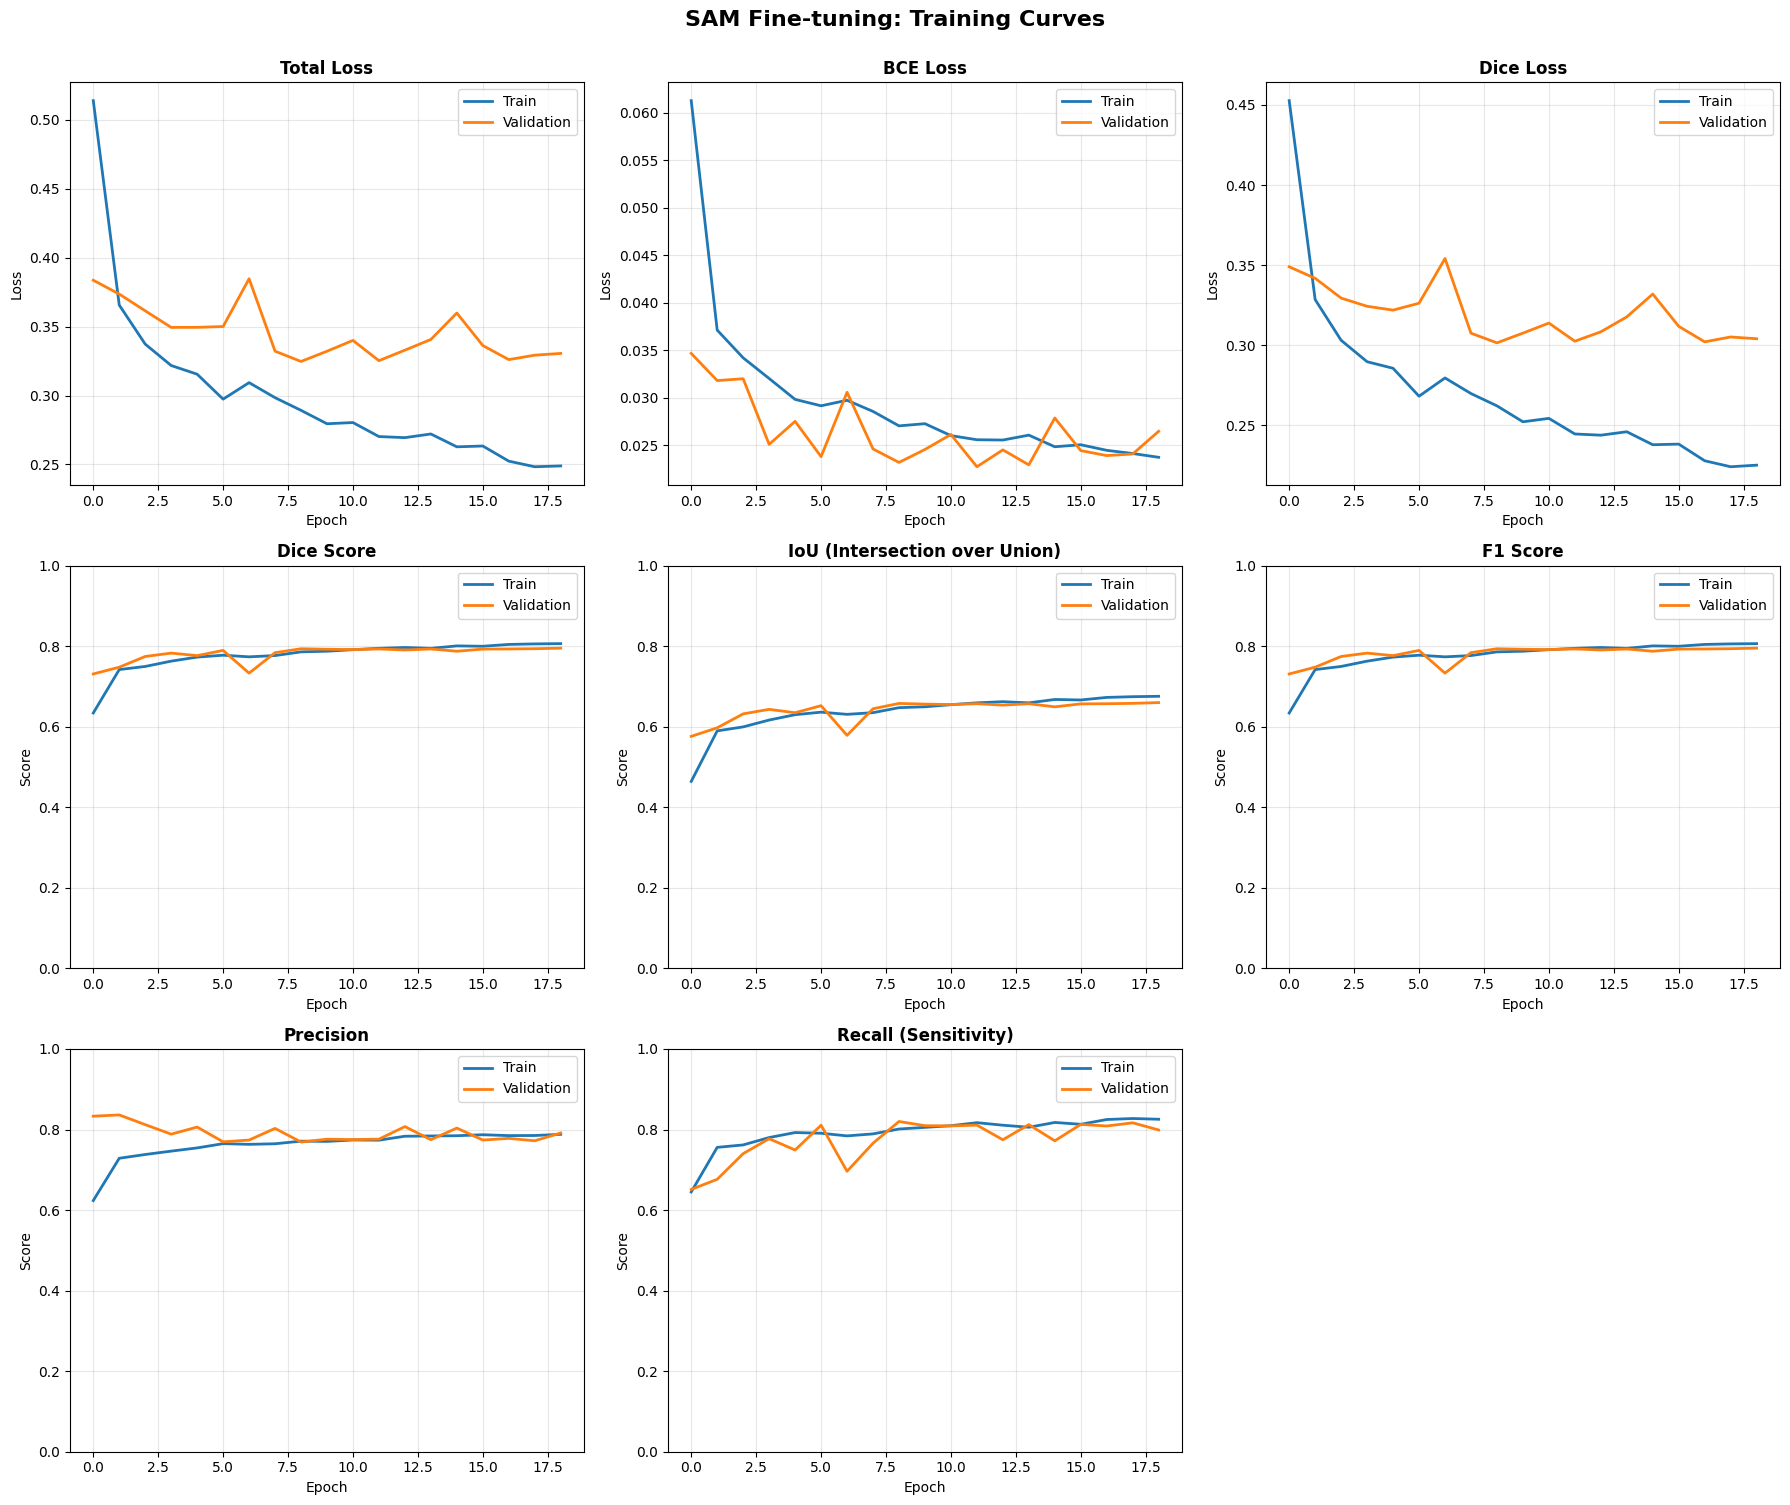

In [ ]:
plot_all_metrics(history)

Loaded best model from epoch 9
Best Validation Recall: 0.8200
Applied LoRA (rank=32) to 12 transformer blocks
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Testing: 100%|██████████| 9/9 [01:17<00:00,  8.56s/it]


TILE-LEVEL TEST RESULTS
Loss:          0.2633
  - BCE Loss:  0.0109
  - Dice Loss: 0.2525

Segmentation Metrics:
  Dice:        0.7745
  IoU:         0.6319
  Precision:   0.7574
  Recall:      0.7923
  F1:          0.7745
Visualizing 6 random samples...



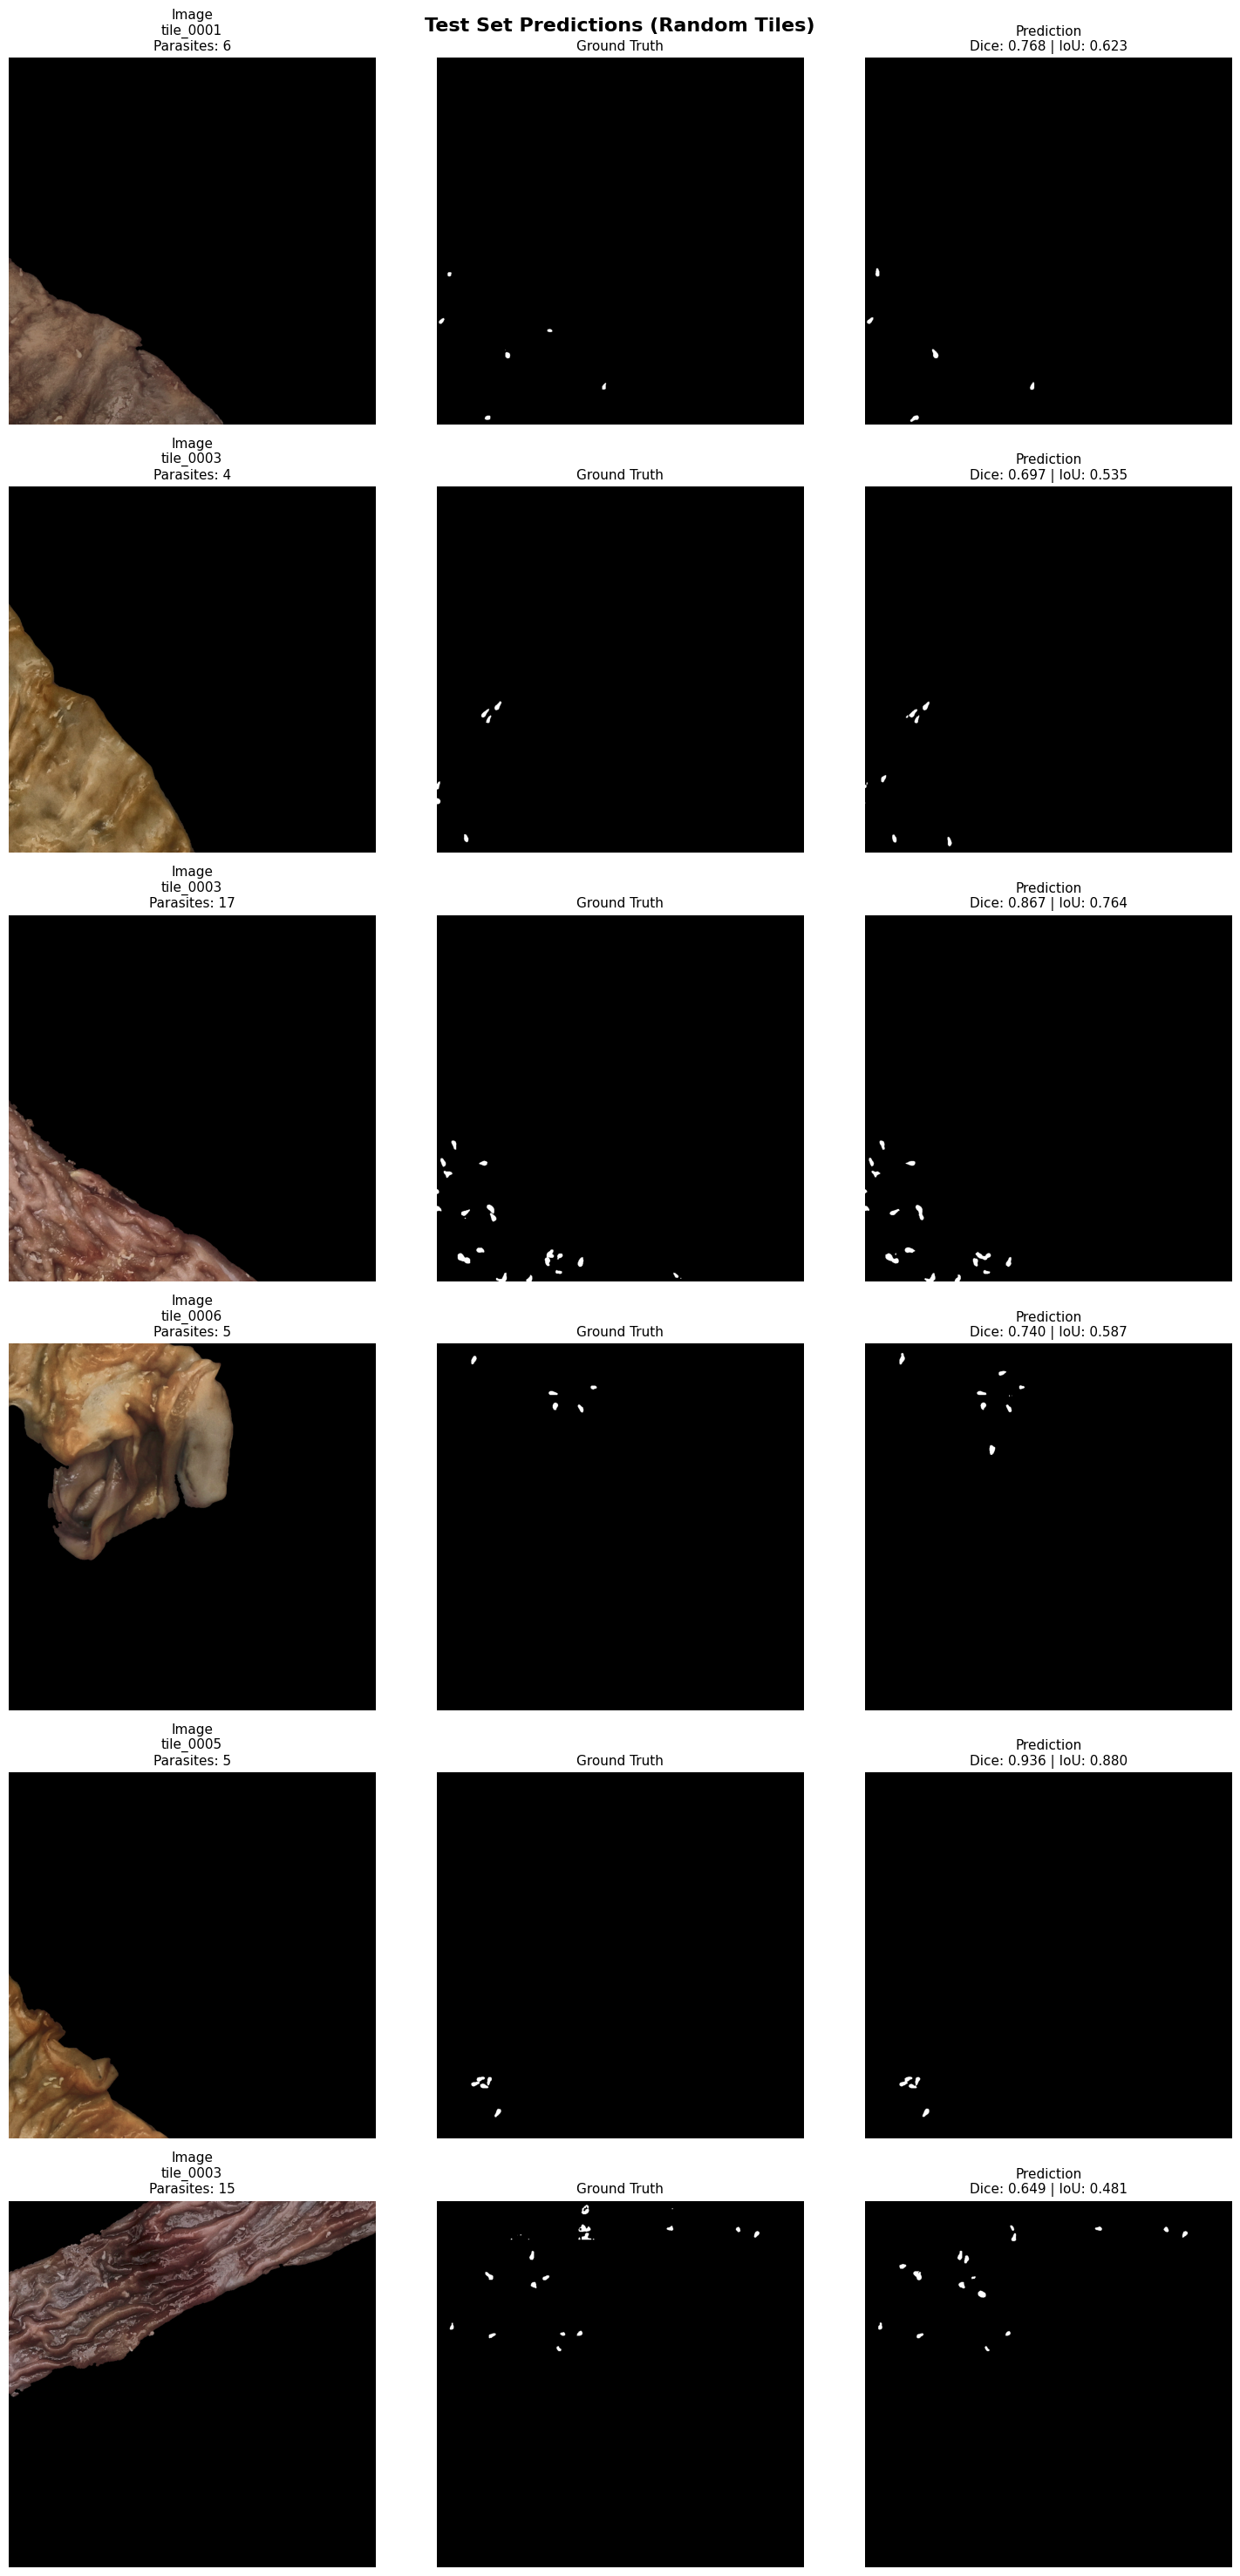

In [ ]:
import torch.serialization
import numpy as np

torch.serialization.add_safe_globals([np.core.multiarray.scalar])

best_checkpoint_path = f"{checkpoint_dir}/sam_best.pth"

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False
)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Recall: {checkpoint['best_val_recall']:.4f}")

sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=checkpoint['lora_rank'],
    learning_rate=1e-4,
    bce_weight=checkpoint['bce_weight'],
    dice_weight=checkpoint['dice_weight']
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval()

test_results = evaluate_on_test(
    fine_tuner=eval_fine_tuner,
    test_dataset=test_dataset,
    batch_size=4,
    visualize=True,         # Show some example predictions
    num_viz_samples=6       # Number of tiles to visualize
)


FULL IMAGE RECONSTRUCTION WITH VISUALIZATION
Testing on 6 images: ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']

Processing: B2025-00231b...
  Reconstructing: 4096 x 2805 (~131.5MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7443 | IoU: 0.5927 | Precision: 0.7967 | Recall: 0.6983

Processing: B2025-00143b...
  Reconstructing: 3707 x 3687 (~156.4MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7427 | IoU: 0.5907 | Precision: 0.7136 | Recall: 0.7742

Processing: B2025-00206b...
  Reconstructing: 3660 x 3072 (~128.7MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.8260 | IoU: 0.7036 | Precision: 0.8754 | Recall: 0.7819

Processing: B2025-00136b...
  Reconstructing: 4025 x 3433 (~158.1MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.8304 | IoU: 0.7099 | Precision: 0.8674 | Recall: 0.7964

Processing: B2025-00085.2...
  Reconstructing: 3207 x 3581 (~131.4MB, 9 tiles)
  Successfully processed 9/9 tiles
 

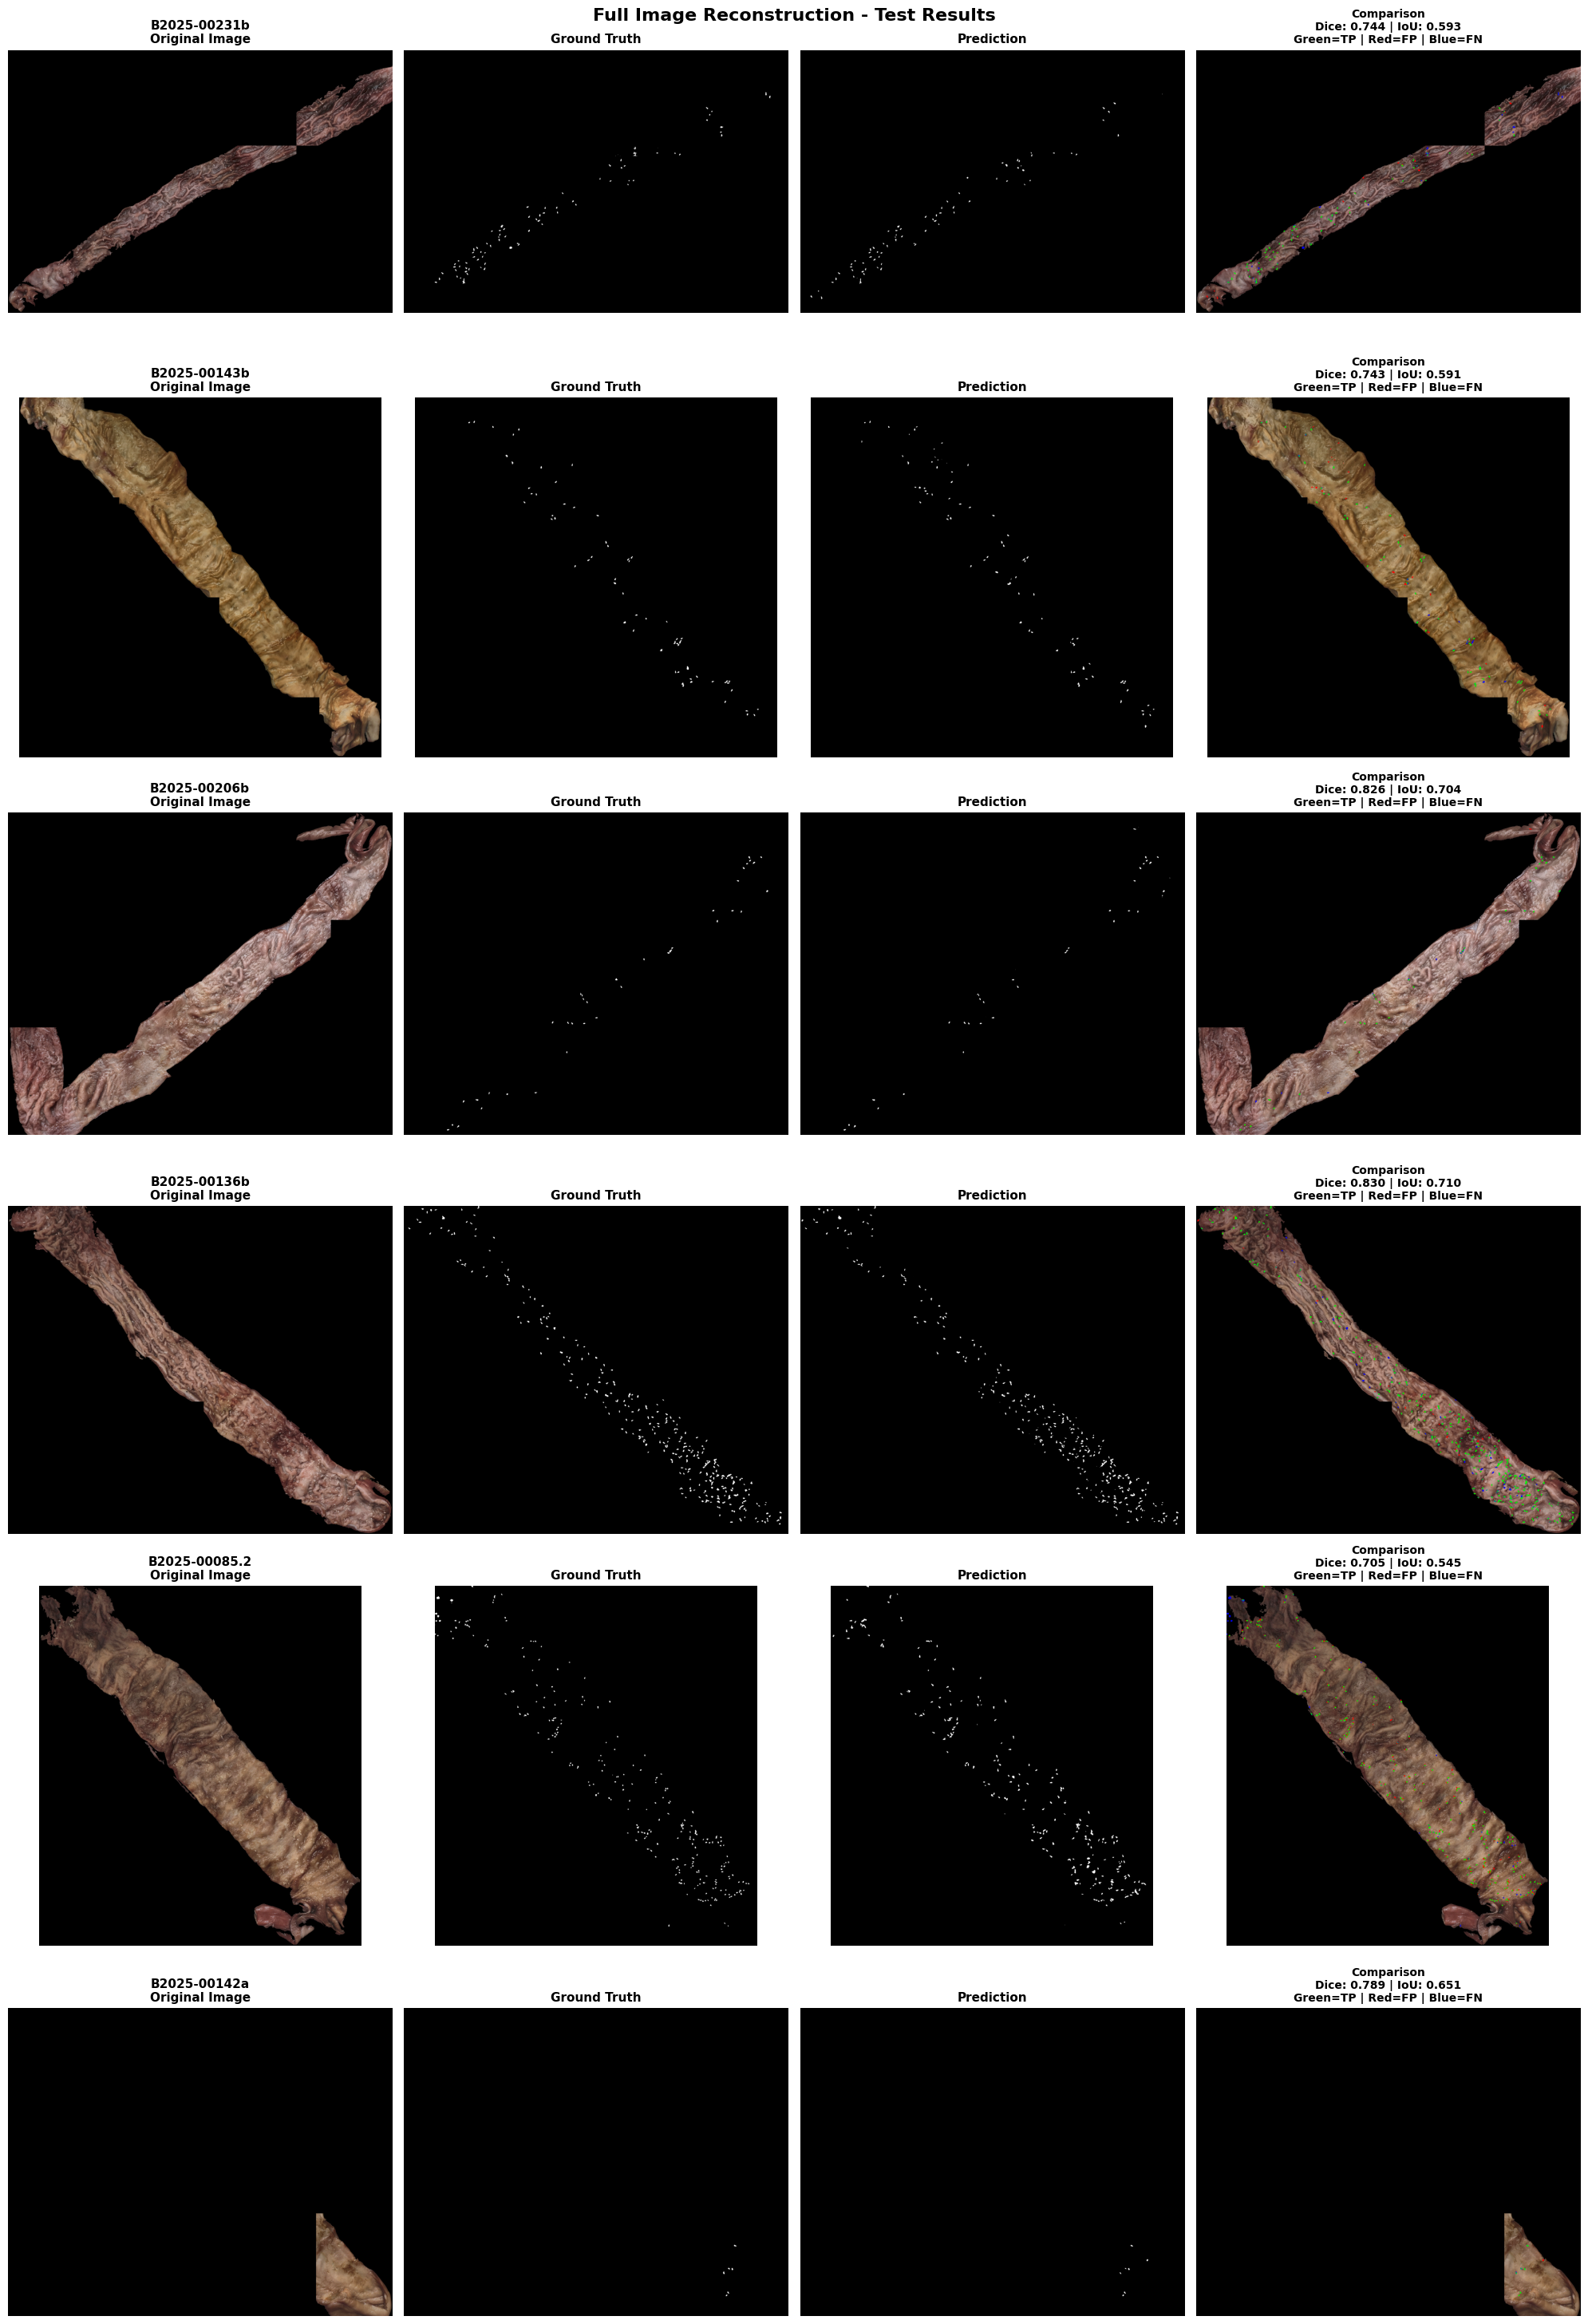

In [ ]:
results_df, visualizations = evaluate_full_images(
    fine_tuner=eval_fine_tuner,
    splits=splits,
    test_dataset=test_dataset,
    max_image_size_mb=300,                  # Skip images larger than 300MB
    process_in_chunks=True,                 # Process tiles in chunks
    chunk_size=30,                          # Clear cache every 30 tiles
)

## Experiment 2 - LoRA 32, AdamW,Augm



In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class SAMDatasetNoPrompt(Dataset):
    """Dataset for SAM fine-tuning with Albumentations"""

    def __init__(self, image_ids, output_dir, augment=False, transform=None):
        """
        Args:
            image_ids: List of image IDs
            output_dir: Directory containing processed tiles
            augment: Whether to use augmentation (for backward compatibility)
            transform: Albumentations transform pipeline (overrides augment if provided)
        """
        self.samples = []
        self.augment = augment
        self.transform = transform  # Albumentations transform

        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            masks_dir = os.path.join(output_dir, img_id, "masks")
            annotations_dir = os.path.join(output_dir, img_id, "annotations")

            if not os.path.exists(tiles_dir):
                continue

            tile_files = [f for f in os.listdir(tiles_dir) if f.endswith('.png')]

            for tile_file in tile_files:
                tile_id = tile_file.replace('.png', '')
                tile_path = os.path.join(tiles_dir, tile_file)
                mask_path = os.path.join(masks_dir, f"{tile_id}.png")
                anno_path = os.path.join(annotations_dir, f"{tile_id}.json")

                if os.path.exists(mask_path) and os.path.exists(anno_path):
                    with open(anno_path, 'r') as f:
                        anno = json.load(f)

                    self.samples.append({
                        'tile_path': tile_path,
                        'mask_path': mask_path,
                        'tile_id': tile_id,
                        'base_image_id': img_id,
                        'num_parasites': anno['num_parasites']
                    })

        aug_type = "Albumentations" if self.transform else ("Basic" if self.augment else "None")
        print(f"Loaded {len(self.samples)} samples (augmentation={aug_type})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image and mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)

        # Binary mask (0 or 1)
        binary_mask = (mask > 127).astype(np.uint8)

        # Apply Albumentations transform if provided
        if self.transform is not None:
            transformed = self.transform(image=image, mask=binary_mask)
            image = transformed['image']
            mask_tensor = transformed['mask']

            # Normalize image to [0, 1] for SAM
            image_tensor = image.float() / 255.0

            # Ensure mask is float and has correct shape [1, H, W]
            if mask_tensor.dim() == 2:
                mask_tensor = mask_tensor.unsqueeze(0)
            mask_tensor = mask_tensor.float()

        # Fallback to basic augmentation (for backward compatibility)
        elif self.augment:
            if random.random() > 0.5:
                image = cv2.flip(image, 1).copy()
                binary_mask = cv2.flip(binary_mask, 1).copy()
            if random.random() > 0.5:
                image = cv2.flip(image, 0).copy()
                binary_mask = cv2.flip(binary_mask, 0).copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

            # Convert to tensors
            image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        # No augmentation
        else:
            image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'tile_id': sample['tile_id'],
            'num_parasites': sample['num_parasites']
        }

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2


train_transforms = A.Compose([
    # Geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.Rotate(limit=5, p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.25,
        rotate_limit=0,
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        mask_value=0
    ),
    A.Affine(
        shear=(-2, 2),
        p=0.3,
        mode=cv2.BORDER_CONSTANT,
        cval=0,
        cval_mask=0
    ),

    # Color augmentations
    A.HueSaturationValue(
        hue_shift_limit=int(0.015 * 180),
        sat_shift_limit=int(0.7 * 255),
        val_shift_limit=int(0.4 * 255),
        p=0.9
    ),

    # Additional augmentations
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.1),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    # Convert to tensor (image will be normalized to [0,1] in __getitem__)
    ToTensorV2(),
])

# Validation: No augmentation, just convert to tensor
val_transforms = A.Compose([
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-3488974880.py:10: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipython-input-3488974880.py:19: UserWarning: Argument(s) 'mode, cval, cval_mask' are not valid for transform Affine
  A.Affine(


In [ ]:
# Create datasets
train_dataset = SAMDatasetNoPrompt(
    image_ids=splits['train'],
    output_dir=output_dir,
    transform=train_transforms
)

val_dataset = SAMDatasetNoPrompt(
    image_ids=splits['val'],
    output_dir=output_dir,
    transform=val_transforms
)

test_dataset = SAMDatasetNoPrompt(
    image_ids=splits['test'],
    output_dir=output_dir,
    transform=val_transforms
)


Loaded 229 samples (augmentation=Albumentations)
Loaded 30 samples (augmentation=Albumentations)
Loaded 36 samples (augmentation=Albumentations)


In [ ]:
sam_model, device = load_sam_model()

config = {
    'exp_name': '32_augm_recall',
    'batch_size': 1,
    'num_epochs': 30,
    'learning_rate': 1e-4,
    'lora_rank': 32,
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'bce_weight': 1.0,
    'dice_weight': 1.0,
    'grad_clip': None,
    'scheduler': None,
    'early_stop_patience': 10
}

history, fine_tuner, checkpoint_dir = train_sam_lora(sam_model, train_dataset, val_dataset, config)

Checkpoints will be saved to: /content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/32_augm_recall
Applied LoRA (rank=32) to 12 transformer blocks
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Epoch 1/30 [Train]: 100%|██████████| 229/229 [03:38<00:00,  1.05it/s, loss=0.3467, dice=0.4358, iou=0.2786]



Epoch 1/30
 Train | Loss: 0.7425 | Dice: 0.4358 | IoU: 0.2786
       | Precision: 0.4605 | Recall: 0.4137 | F1: 0.4358
 Val   | Loss: 0.4732 | Dice: 0.7207 | IoU: 0.5634
       | Precision: 0.7152 | Recall: 0.7264 | F1: 0.7207

New best model saved (Recall: 0.7264)


Epoch 2/30 [Train]: 100%|██████████| 229/229 [02:19<00:00,  1.65it/s, loss=0.3800, dice=0.6610, iou=0.4936]



Epoch 2/30
 Train | Loss: 0.4842 | Dice: 0.6610 | IoU: 0.4936
       | Precision: 0.6751 | Recall: 0.6474 | F1: 0.6610
 Val   | Loss: 0.3523 | Dice: 0.7356 | IoU: 0.5818
       | Precision: 0.8281 | Recall: 0.6617 | F1: 0.7356


...


Epoch 12/30
 Train | Loss: 0.3910 | Dice: 0.7204 | IoU: 0.5630
       | Precision: 0.7245 | Recall: 0.7163 | F1: 0.7204
 Val   | Loss: 0.3106 | Dice: 0.7846 | IoU: 0.6455
       | Precision: 0.7886 | Recall: 0.7806 | F1: 0.7846


Epoch 13/30 [Train]: 100%|██████████| 229/229 [02:18<00:00,  1.65it/s, loss=0.2822, dice=0.7225, iou=0.5656]



Epoch 13/30
 Train | Loss: 0.3940 | Dice: 0.7225 | IoU: 0.5656
       | Precision: 0.7254 | Recall: 0.7197 | F1: 0.7225
 Val   | Loss: 0.3386 | Dice: 0.7811 | IoU: 0.6408
       | Precision: 0.7855 | Recall: 0.7767 | F1: 0.7811


Epoch 14/30 [Train]: 100%|██████████| 229/229 [02:18<00:00,  1.65it/s, loss=0.2374, dice=0.7185, iou=0.5606]



Epoch 14/30
 Train | Loss: 0.4039 | Dice: 0.7185 | IoU: 0.5606
       | Precision: 0.7257 | Recall: 0.7114 | F1: 0.7185
 Val   | Loss: 0.3148 | Dice: 0.7889 | IoU: 0.6514
       | Precision: 0.7828 | Recall: 0.7952 | F1: 0.7889

Early stopping triggered at epoch 14


Loaded best model from epoch 4
Best Validation Recall: 0.8612
Applied LoRA (rank=32) to 12 transformer blocks
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Testing: 100%|██████████| 9/9 [01:44<00:00, 11.64s/it]


TILE-LEVEL TEST RESULTS
Loss:          0.3172
  - BCE Loss:  0.0122
  - Dice Loss: 0.3049

Segmentation Metrics:
  Dice:        0.7403
  IoU:         0.5877
  Precision:   0.6479
  Recall:      0.8634
  F1:          0.7403
Visualizing 6 random samples...



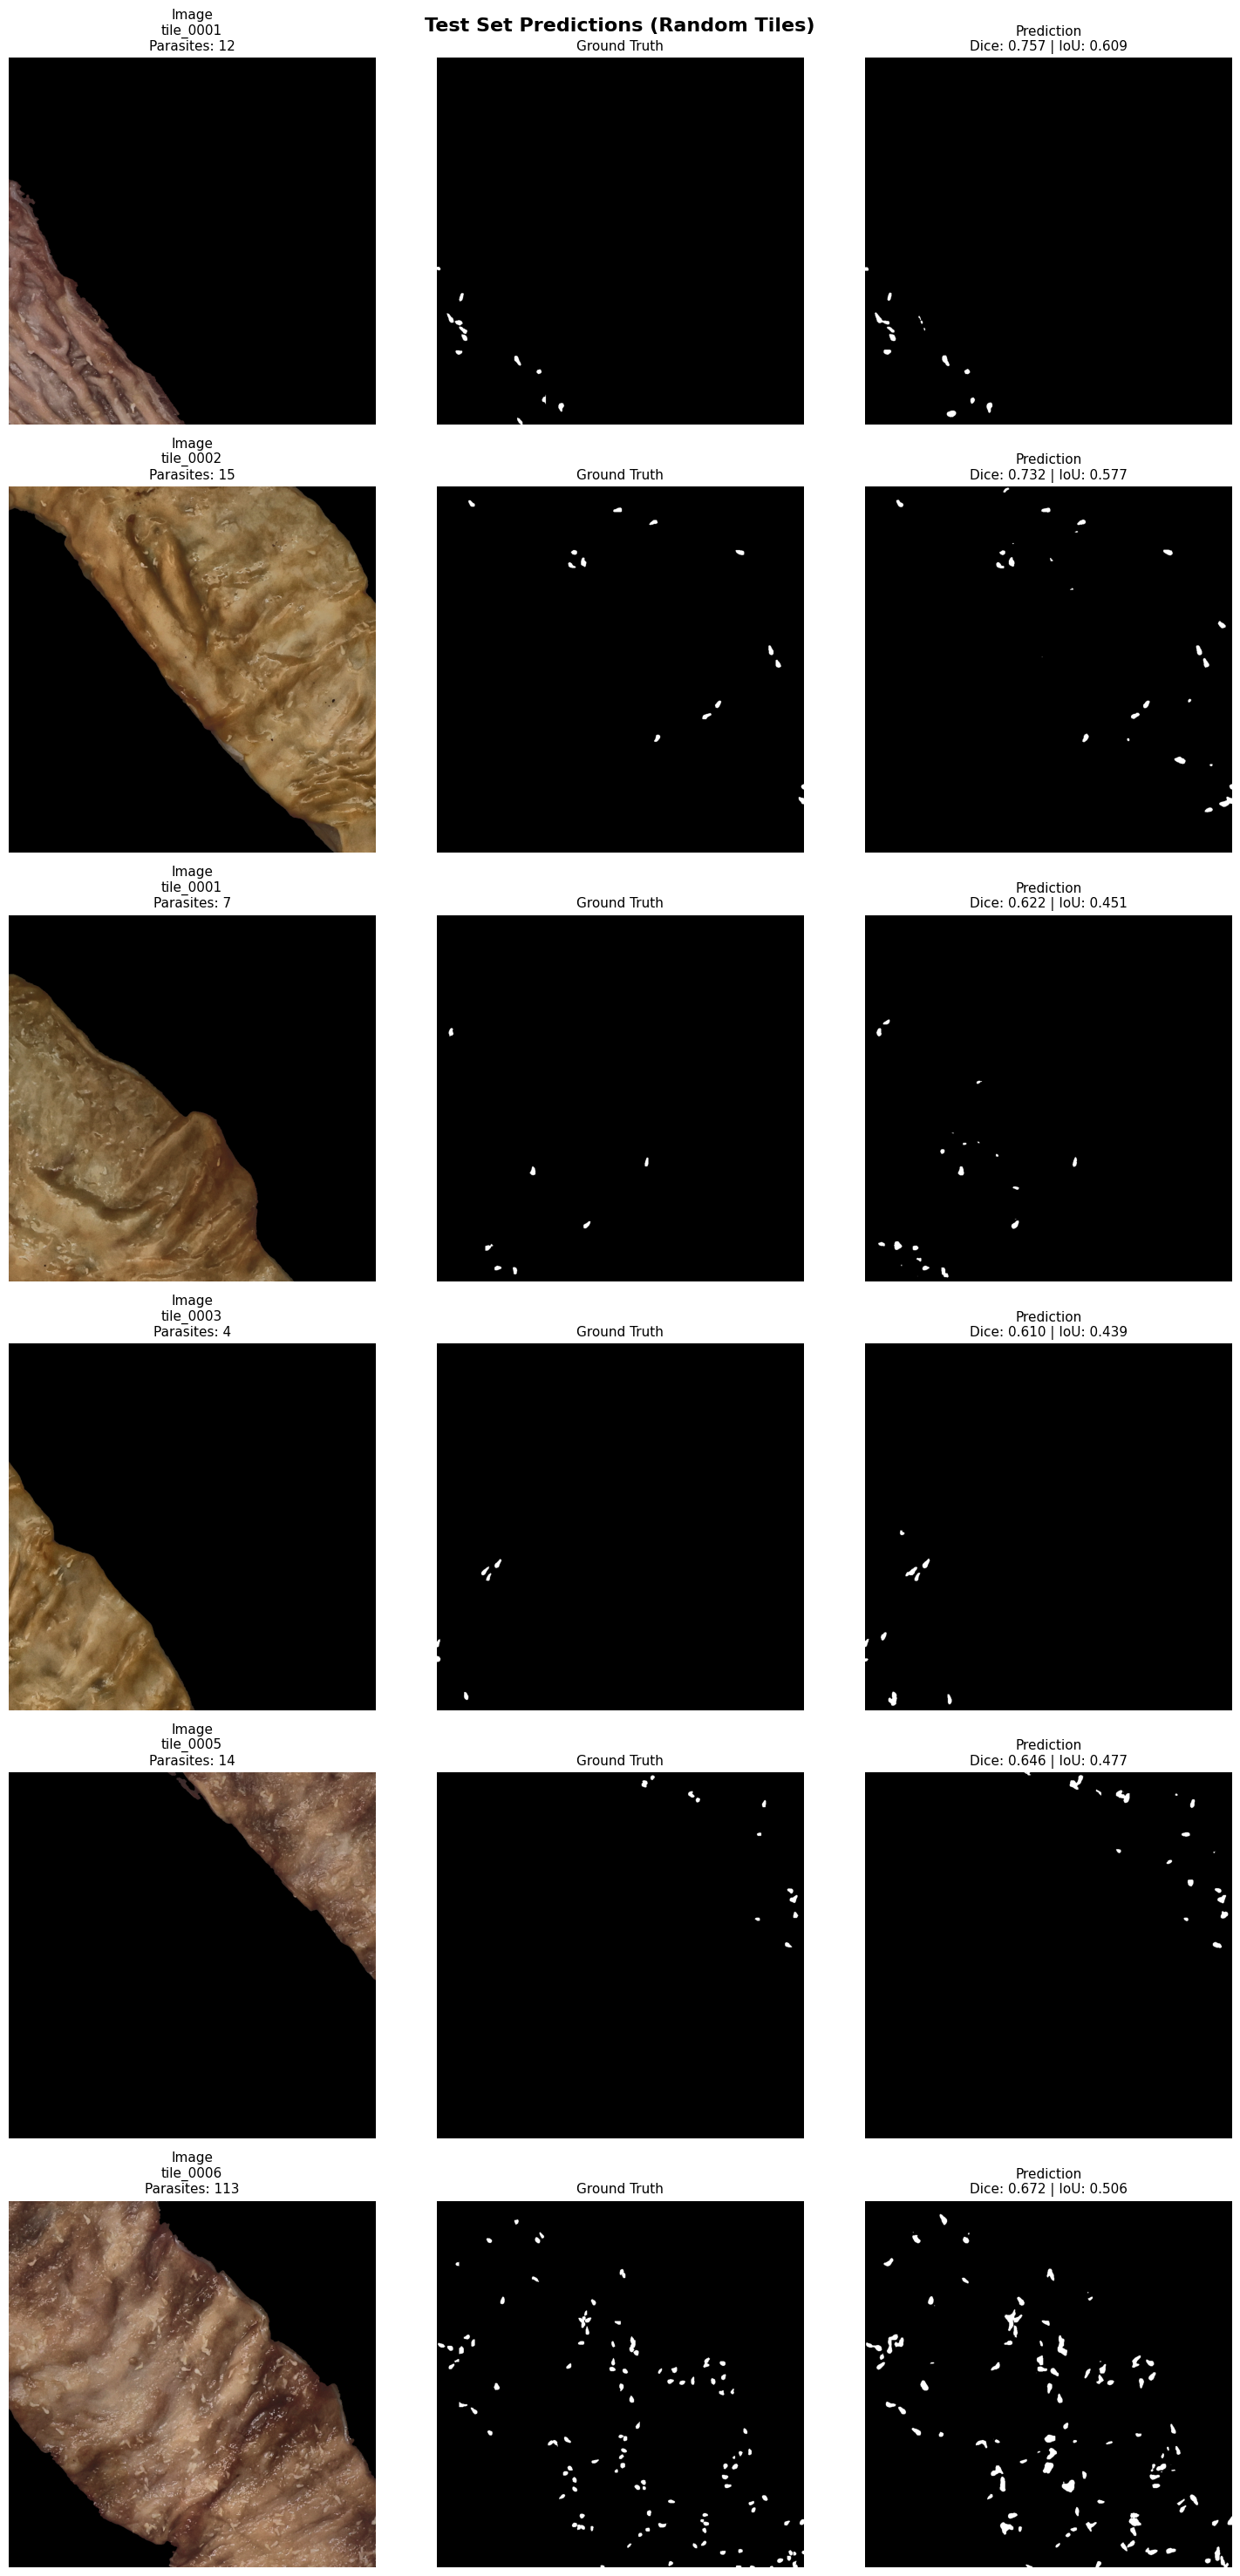

In [ ]:
import torch.serialization
import numpy as np

torch.serialization.add_safe_globals([np.core.multiarray.scalar])

best_checkpoint_path = f"{checkpoint_dir}/sam_best.pth"

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False
)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Recall: {checkpoint['best_val_recall']:.4f}")

sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=checkpoint['lora_rank'],
    learning_rate=1e-4,
    bce_weight=checkpoint['bce_weight'],
    dice_weight=checkpoint['dice_weight']
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval()

test_results = evaluate_on_test(
    fine_tuner=eval_fine_tuner,
    test_dataset=test_dataset,
    batch_size=4,
    visualize=True,         # Show some example predictions
    num_viz_samples=6       # Number of tiles to visualize
)


FULL IMAGE RECONSTRUCTION WITH VISUALIZATION
Testing on 6 images: ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']

Processing: B2025-00231b...
  Reconstructing: 4096 x 2805 (~131.5MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7352 | IoU: 0.5813 | Precision: 0.6580 | Recall: 0.8330

Processing: B2025-00143b...
  Reconstructing: 3707 x 3687 (~156.4MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7273 | IoU: 0.5714 | Precision: 0.6233 | Recall: 0.8729

Processing: B2025-00206b...
  Reconstructing: 3660 x 3072 (~128.7MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7418 | IoU: 0.5896 | Precision: 0.6425 | Recall: 0.8774

Processing: B2025-00136b...
  Reconstructing: 4025 x 3433 (~158.1MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.8087 | IoU: 0.6788 | Precision: 0.7611 | Recall: 0.8626

Processing: B2025-00085.2...
  Reconstructing: 3207 x 3581 (~131.4MB, 9 tiles)
  Successfully processed 9/9 tiles
 

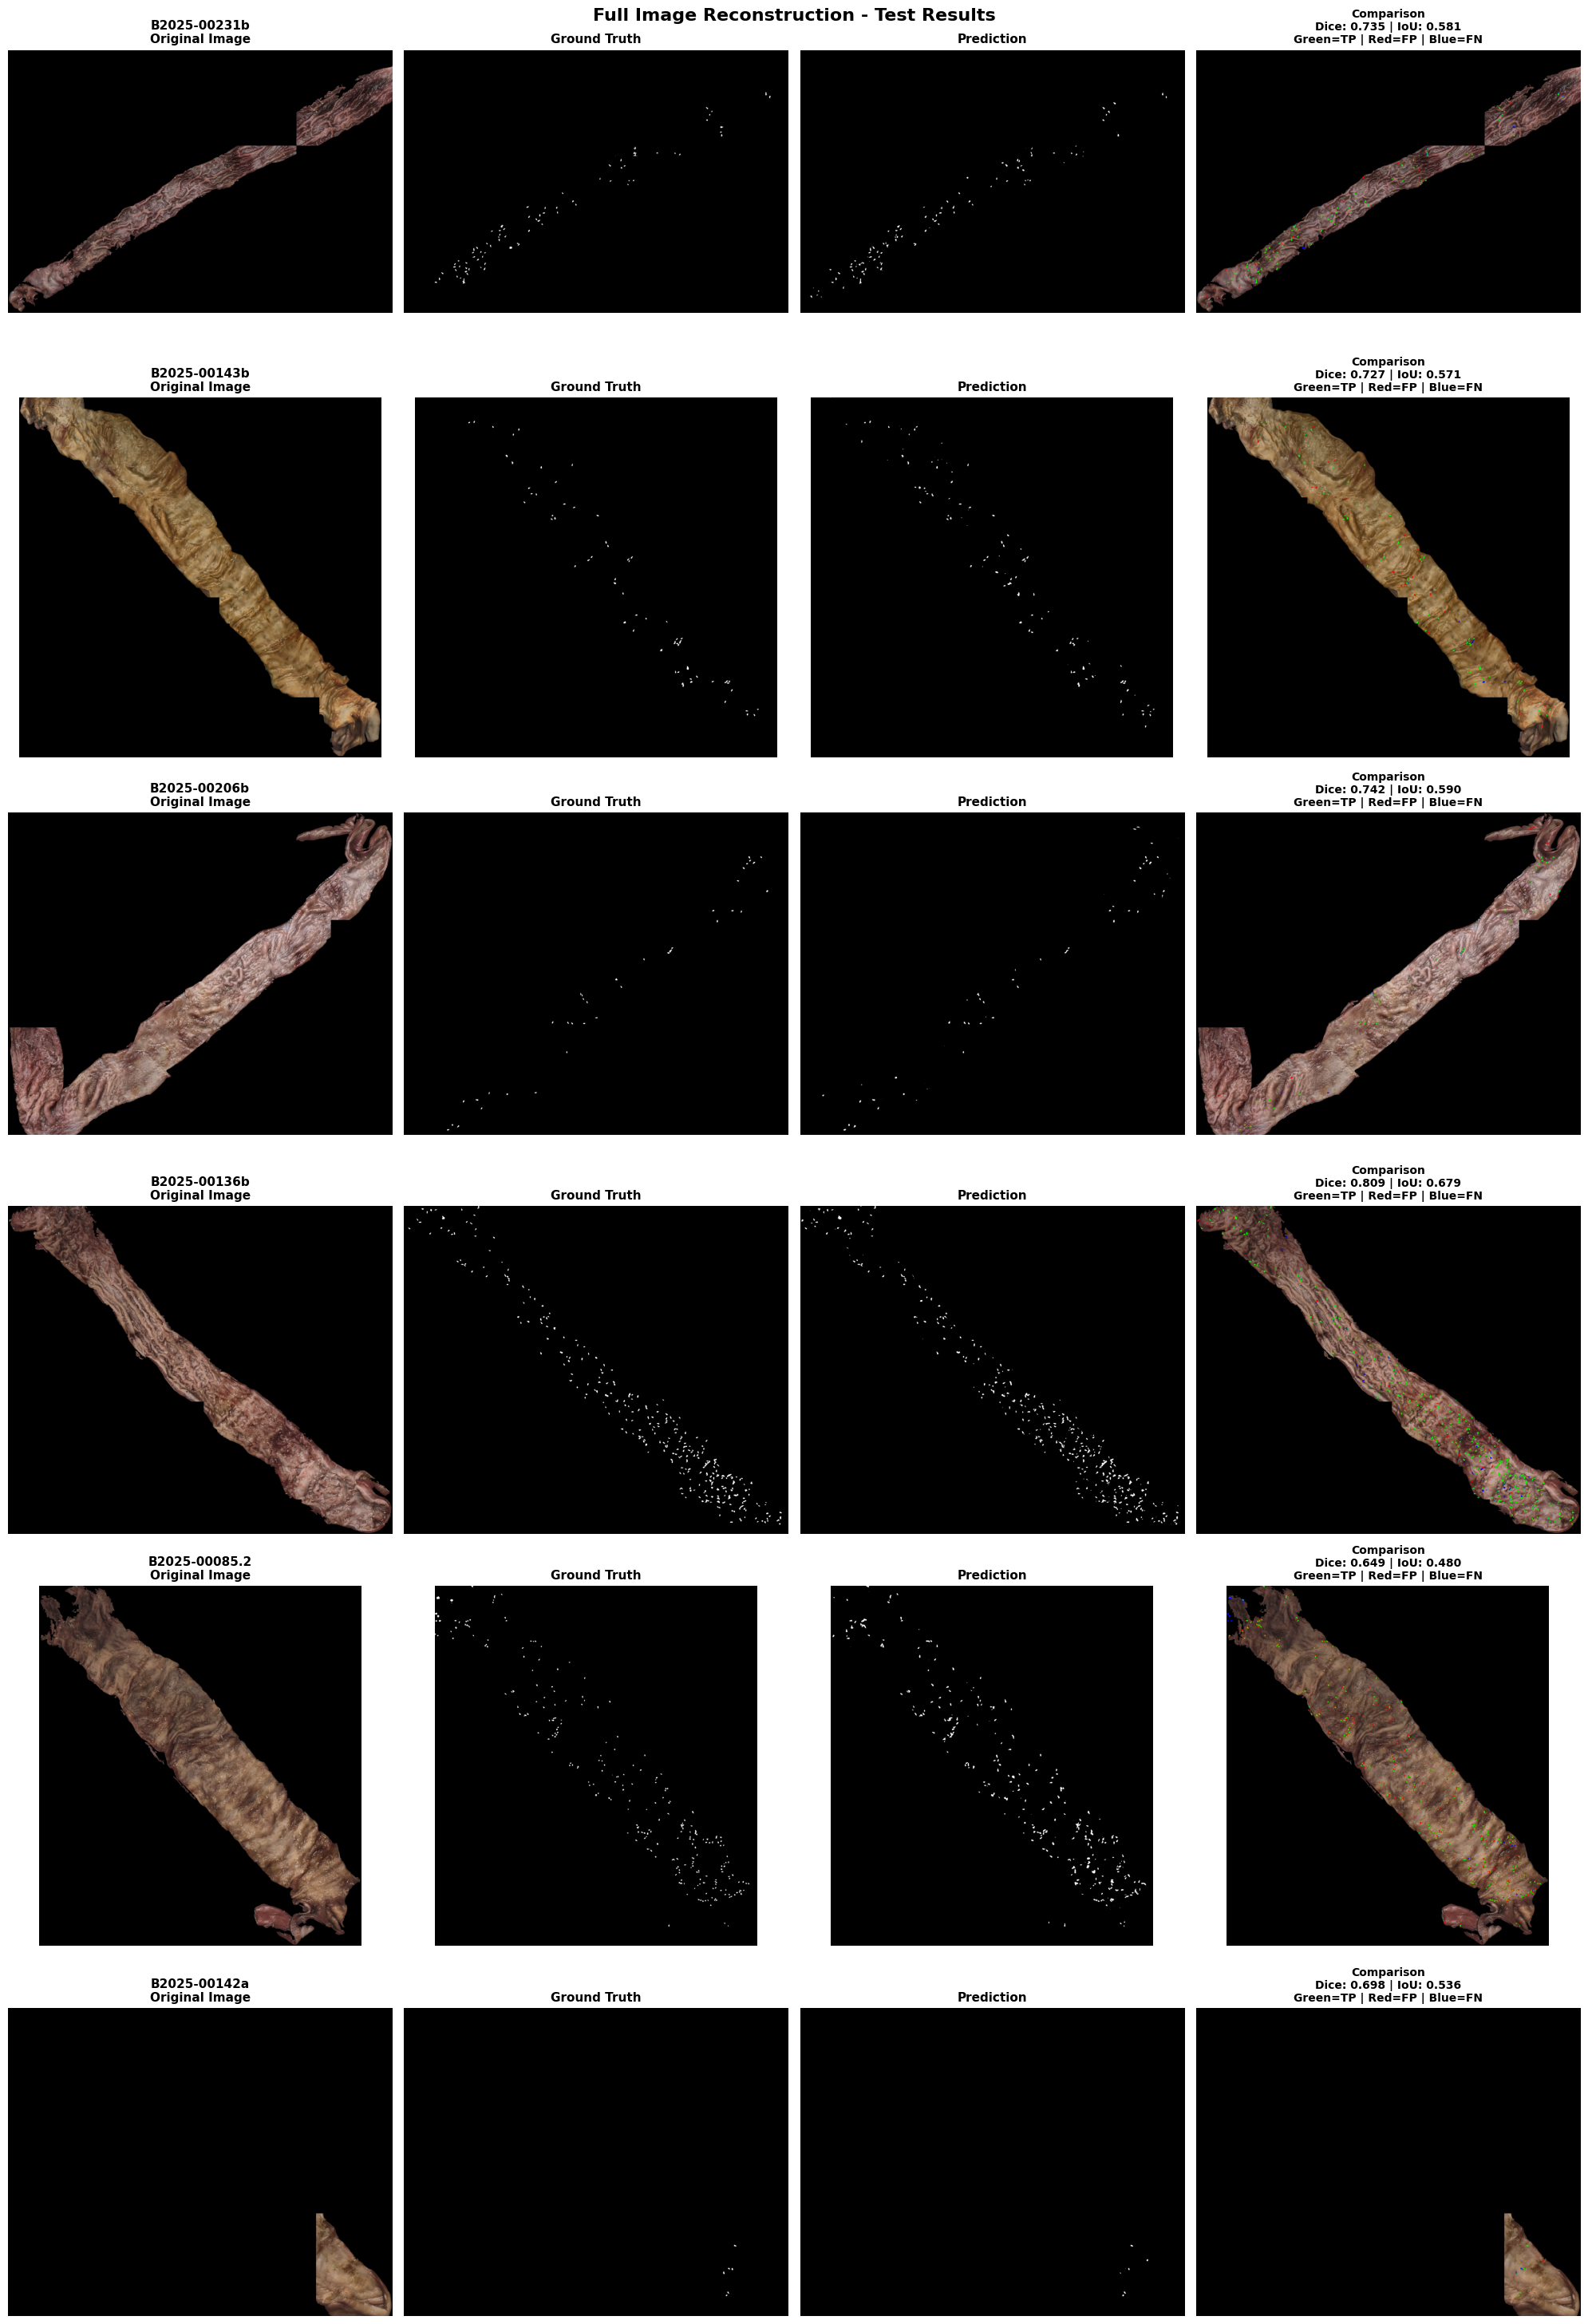

In [ ]:
results_df, visualizations = evaluate_full_images(
    fine_tuner=eval_fine_tuner,
    splits=splits,
    test_dataset=test_dataset,
    max_image_size_mb=300,                  # Skip images larger than 300MB
    process_in_chunks=True,                 # Process tiles in chunks
    chunk_size=30,                          # Clear cache every 30 tiles
)